# 3D Plotting with Matplotlib
## Milestone 3: Visualize on a 3D Surface Plot

### Objective
In this milestone, you will visualize the patterns in bikes rented hourly in each month. You will create three 3-dimensional plots—a wireframe plot, contour plot, and surface plot with month names on the x-axis, hours on the y-axis, and mean number of bikes rented on the z-axis. You will add a new column Month to your DataFrame for this. This Month column will be extracted from the Date column in original datafile. You will use a pivot table to get data ready for your plot. You will also learn to rotate the axis of your 3D plot by specific elevation and azimuth in degrees.    

### Importance of the Project
The 3D plots created in this milestone will enable you to visualize the influence of two features—hour of the day and month of the year on the mean number of bikes rented. You will learn how to create and customize your plot, add subplots to your figure, and rotate a plot.

### 1. Import libraries and read the dataset into a DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from mpl_toolkits import mplot3d

In [3]:
data_loc = "./data/"
img_loc = "./img/"

In [4]:
bikes = pd.read_csv(data_loc + "SeoulBikeData.csv",  
                    encoding = 'unicode_escape',   
                    parse_dates=['Date'],
                    date_format = "%d/%m/%Y"  
                  )

In [5]:
bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8760 non-null   datetime64[ns]
 1   Rented Bike Count          8760 non-null   int64         
 2   Hour                       8760 non-null   int64         
 3   Temperature(°C)            8760 non-null   float64       
 4   Humidity(%)                8760 non-null   int64         
 5   Wind speed (m/s)           8760 non-null   float64       
 6   Visibility (10m)           8760 non-null   int64         
 7   Dew point temperature(°C)  8760 non-null   float64       
 8   Solar Radiation (MJ/m2)    8760 non-null   float64       
 9   Rainfall(mm)               8760 non-null   float64       
 10  Snowfall (cm)              8760 non-null   float64       
 11  Seasons                    8760 non-null   object        
 12  Holida

In [6]:
bikes.sample(5)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
6751,2018-09-08,511,7,16.0,70,1.1,2000,10.5,0.11,0.0,0.0,Autumn,No Holiday,Yes
8510,2018-11-20,790,14,12.3,16,2.5,1797,-12.8,1.69,0.0,0.0,Autumn,No Holiday,Yes
140,2017-12-06,190,20,1.2,94,0.6,228,0.3,0.00,0.0,1.0,Winter,No Holiday,Yes
4439,2018-06-03,1274,23,22.0,44,0.8,1978,9.1,0.00,0.0,0.0,Summer,No Holiday,Yes
355,2017-12-15,451,19,0.6,41,1.2,1550,-11.1,0.00,0.0,0.0,Winter,No Holiday,Yes


### 2. Add a new column Month to your DataFrame

In [7]:
from datetime import datetime

In [8]:
bikes["Month"] = bikes["Date"].dt.month

#### **1. What the code does**

```python
bikes["Month"] = bikes["Date"].dt.month
```

* Creates a new column called `"Month"` in the `bikes` DataFrame.
* Extracts the month number (1–12) from the existing `"Date"` column.
* Stores those values in the new `"Month"` column.

---

#### **2. Code Breakdown**

1. **`bikes["Date"]`**

   * Accesses the `"Date"` column in the `bikes` DataFrame.
   * This column must be of type `datetime64[ns]` (Pandas datetime type).

2. **`.dt`**

   * A special Pandas accessor for datetime-like columns.
   * Lets you pull out components such as `.year`, `.month`, `.day`, `.weekday`, `.hour`, etc.

3. **`.month`**

   * Extracts the month as an integer (January = 1, February = 2, …, December = 12).

4. **`bikes["Month"] = ...`**

   * Assigns the result back to a new column in the DataFrame.
   * Now every row has both the full date (`"Date"`) and the numeric month (`"Month"`).


#### **3. Why this is useful**

* Adds a categorical grouping variable for analysis and plotting.
* Lets you do things like:
  * Group rentals by month: `bikes.groupby("Month")["Rented Bike Count"].mean()`.
  * Plot seasonal trends.
* Keeps the original date intact for more granular analysis later.

---

**In short:**
This line pulls the month number from the date and stores it in a new column so you can analyze bike rentals month by month.

In [9]:
bikes[["Date","Month"]].sample(10)

,Date,Month
7534,2018-10-10,10
7152,2018-09-25,9
7405,2018-10-05,10
7741,2018-10-19,10
6260,2018-08-18,8
1376,2018-01-27,1
8594,2018-11-24,11
8141,2018-11-05,11
2968,2018-04-03,4
4219,2018-05-25,5


In [10]:
# This line of code creates a list of all Matplotlib rcParams (runtime configuration parameters) whose names contain the string "wspace".
# It identifies parameters that control horizontal spacing between subplots, such as "figure.subplot.wspace".
[param for param in list(plt.rcParams.keys()) if "wspace" in param]

['figure.constrained_layout.wspace', 'figure.subplot.wspace']

In [11]:
# This code uses a list comprehension with pandas.Timestamp to generate a list of abbreviated month names ('Jan' through 'Dec'). 
# For each month number from 1 to 12, it creates a dummy date (day=1, year=2024), extracts the month name, and slices it to the first three characters.
month_names = [pd.Timestamp(year = 2024, day = 1, month = m).month_name()[:3] for m in range(1,13)]
month_names

['Jan',
 'Feb',
 'Mar',
 'Apr',
 'May',
 'Jun',
 'Jul',
 'Aug',
 'Sep',
 'Oct',
 'Nov',
 'Dec']

#### Code Explanation

```python
month_names = [pd.Timestamp(year=2024, day=1, month=m).month_name()[:3] for m in range(1,13)]
```

1. **`for m in range(1, 13)`**

   * Loops through the numbers `1` to `12`.
   * Each number represents a month of the year (1 = January, 2 = February, … 12 = December).

2. **`pd.Timestamp(year=2024, day=1, month=m)`**

   * Creates a Pandas Timestamp object, which is like a smart datetime object.
   * Example: `pd.Timestamp(year=2024, month=3, day=1)` → `"2024-03-01 00:00:00"`.
   * The year (2024) and day (1) are arbitrary here — the important part is the month (`m`).

3. **`.month_name()`**

   * Returns the full month name from the timestamp.
   * Example: `pd.Timestamp(..., month=3).month_name()` → `"March"`.

4. **`[:3]`**

   * Slices the string to keep only the first 3 characters.
   * `"March"[:3]` → `"Mar"`.

5. **List comprehension**

   * Builds a list of all the 3-letter month abbreviations.

In [12]:
months = pd.Series(month_names, index = range(1,13))
months

1     Jan
2     Feb
3     Mar
4     Apr
5     May
6     Jun
7     Jul
8     Aug
9     Sep
10    Oct
11    Nov
12    Dec
dtype: object

### 3. Create a pivot table for Rented Bike Count, with Hour as index and Month as columns
This pivot table will contain the mean of Rented Bike Counts for every hour for every month. Round these values to two decimal places using round() function.

In [13]:
bikes[["Hour","Month","Rented Bike Count"]].sample(5)

,Hour,Month,Rented Bike Count
8208,0,11,395
2427,3,3,60
5693,5,7,306
1992,0,2,195
3071,23,4,368


In [14]:
# This line groups the bikes dataset by both hour of the day and month, 
# then calculates the mean number of rentals for each hour–month combination. 
# The results are rounded to two decimals, and then first eight rows are displayed as a preview.
# The idea is to use this to check the results of the pivot_table method in the next cell
bikes[["Hour","Month","Rented Bike Count"]].groupby(["Hour","Month"]).mean().round(2).head(8)

Rented Bike Count
Hour Month                   
0    1                 144.10
     2                 146.89
     3                 295.39
     4                 474.30
     5                 642.32
     6                 989.17
     7                 881.65
     8                 829.29

In [15]:
# This code builds a pivot table where each row represents an hour of the day (0–23), 
# each column represents a month (1–12), 
# and each cell contains the mean number of bikes rented at that hour and month. 
# The results are rounded to two decimals, producing a compact table of hourly–monthly averages.
bikes.pivot_table(values = "Rented Bike Count",
                               index = "Hour", 
                               columns = "Month", 
                               aggfunc = "mean").round(2)

Month,1,2,3,4,5,6,7,8,9,10,11,12
Hour,,,,,,,,,,,,
0,144.10,146.89,295.39,474.30,642.32,989.17,881.65,829.29,763.40,631.23,476.17,202.77
1,138.00,140.43,243.55,346.37,477.87,766.30,692.42,639.77,592.40,477.55,387.47,196.94
2,101.68,99.96,172.65,237.37,332.06,567.07,503.39,448.77,394.80,334.71,265.93,150.00
3,64.94,67.04,110.74,155.07,228.32,369.03,351.10,308.74,265.10,229.61,181.77,100.42
4,43.35,45.93,73.45,98.73,145.19,240.70,229.71,201.58,175.90,150.61,119.20,61.71
5,48.58,44.64,73.65,108.47,158.68,257.80,261.42,218.97,165.07,149.29,116.43,59.81
6,89.52,94.11,157.94,254.47,342.61,509.53,502.19,446.55,353.17,336.55,257.70,94.97
7,194.77,217.32,421.61,622.47,762.32,1031.40,903.06,778.03,725.77,759.71,619.17,217.35
8,397.35,426.64,749.42,1069.97,1223.97,1606.90,1400.61,1254.35,1145.30,1282.48,1161.07,443.03


#### Code Explanation

```python
bikes.pivot_table(
    values="Rented Bike Count",
    index="Hour",
    columns="Month",
    aggfunc="mean"
).round(2)
```

1. **`bikes.pivot_table(...)`**

   * Creates a new table (a DataFrame) where you reorganize your data into rows (`index`), columns (`columns`), and values (`values`).

---

2. **`values="Rented Bike Count"`**

   * This tells Pandas: *“What number should I put inside the table cells?”*
   * Here it’s the `"Rented Bike Count"`.

---

3. **`index="Hour"`**

   * Rows of the pivot table will be hours (0–23).

---

4. **`columns="Month"`**

   * Columns of the pivot table will be months (1–12).

---

5. **`aggfunc="mean"`**

   * Since there could be multiple rows for the same hour and month, Pandas needs to know how to combine them.
   * Here, it takes the average rentals. This means that each cell will contain the average number of rentals at that hour in that month.

---

6. **`.round(2)`**

   * Rounds the final numbers to 2 decimal places.


In [16]:
bikes_grid = bikes.pivot_table(values = "Rented Bike Count",
                               index = "Hour", 
                               columns = "Month", 
                               aggfunc = "mean").round(0).astype(int)

In [17]:
bikes_grid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 0 to 23
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   1       24 non-null     int64
 1   2       24 non-null     int64
 2   3       24 non-null     int64
 3   4       24 non-null     int64
 4   5       24 non-null     int64
 5   6       24 non-null     int64
 6   7       24 non-null     int64
 7   8       24 non-null     int64
 8   9       24 non-null     int64
 9   10      24 non-null     int64
 10  11      24 non-null     int64
 11  12      24 non-null     int64
dtypes: int64(12)
memory usage: 2.4 KB


In [18]:
bikes_grid

Month,1,2,3,4,5,6,7,8,9,10,11,12
Hour,,,,,,,,,,,,
0,144,147,295,474,642,989,882,829,763,631,476,203
1,138,140,244,346,478,766,692,640,592,478,387,197
2,102,100,173,237,332,567,503,449,395,335,266,150
3,65,67,111,155,228,369,351,309,265,230,182,100
4,43,46,73,99,145,241,230,202,176,151,119,62
5,49,45,74,108,159,258,261,219,165,149,116,60
6,90,94,158,254,343,510,502,447,353,337,258,95
7,195,217,422,622,762,1031,903,778,726,760,619,217
8,397,427,749,1070,1224,1607,1401,1254,1145,1282,1161,443


In [19]:
bikes_grid.shape

(24, 12)

### 4. Create a mesh grid of values for plotting 3D plots
Use the NumPy meshgrid() function to create a mesh grid of the values representing length of columns and the length of index of the pivot table created in Step 2. We have twelve columns, one for each month, and 24 rows, one for each hour. The output of meshgrid() is returned in the variables x and y.

### 5. Get the rounded data values from the pivot table in variable z

In [20]:
# `np.meshgrid` generates two coordinate matrices, `X` and `Y`, representing all combinations of month (columns) and hour (rows). 
# These arrays are typically used as input for plotting functions like surface plots or contour plots, where you need explicit x, y grid coordinates alongside your z-values (`bikes_grid`).
X, Y = np.meshgrid(bikes_grid.columns, bikes_grid.index)

#### Code Explanation

```python
X, Y = np.meshgrid(bikes_grid.columns, bikes_grid.index)
```

1. **`bikes_grid.columns`**

   * This is the list of months (`1, 2, 3, …, 12`).

2. **`bikes_grid.index`**

   * This is the list of hours (`0, 1, 2, …, 23`).

3. **`np.meshgrid(...)`**

   * This function takes two 1D arrays (months and hours) and produces two 2D arrays (`X` and `Y`) that represent all combinations of those coordinates.

   * `X` repeats the month values across rows.

   * `Y` repeats the hour values across columns.

These `X, Y` arrays align perfectly with the values in `bikes_grid`, so we can now plot the data in a 2D grid (for example, with a **surface plot** or **contour plot** in Matplotlib).

---

##### Example (simplified)

If months = `[1, 2, 3]` and hours = `[0, 1]`:

```python
X =
[[1, 2, 3],
 [1, 2, 3]]

Y =
[[0, 0, 0],
 [1, 1, 1]]
```

So `(X[i,j], Y[i,j])` gives you the month/hour coordinates for each cell of `bikes_grid`.

In [21]:
bikes_grid.columns.shape

(12,)

In [22]:
bikes_grid.index.shape

(24,)

In [23]:
X

array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,

In [24]:
X.shape

(24, 12)

In [25]:
Y

array([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
       [ 2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2],
       [ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3],
       [ 4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4],
       [ 5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5],
       [ 6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6],
       [ 7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7],
       [ 8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8],
       [ 9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9],
       [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       [11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11],
       [12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12],
       [13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
       [14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14],
       [15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15],
       [16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16],
       [17, 17, 17, 17, 17, 17,

In [26]:
Y.shape

(24, 12)

In [27]:
Z = np.array(bikes_grid)

In [28]:
Z

array([[ 144,  147,  295,  474,  642,  989,  882,  829,  763,  631,  476,
         203],
       [ 138,  140,  244,  346,  478,  766,  692,  640,  592,  478,  387,
         197],
       [ 102,  100,  173,  237,  332,  567,  503,  449,  395,  335,  266,
         150],
       [  65,   67,  111,  155,  228,  369,  351,  309,  265,  230,  182,
         100],
       [  43,   46,   73,   99,  145,  241,  230,  202,  176,  151,  119,
          62],
       [  49,   45,   74,  108,  159,  258,  261,  219,  165,  149,  116,
          60],
       [  90,   94,  158,  254,  343,  510,  502,  447,  353,  337,  258,
          95],
       [ 195,  217,  422,  622,  762, 1031,  903,  778,  726,  760,  619,
         217],
       [ 397,  427,  749, 1070, 1224, 1607, 1401, 1254, 1145, 1282, 1161,
         443],
       [ 240,  253,  490,  661,  817, 1087,  866,  786,  765,  805,  694,
         271],
       [ 170,  188,  395,  555,  725,  920,  658,  599,  683,  682,  544,
         201],
       [ 208,  230,  

In [29]:
Z.shape

(24, 12)

In [30]:
# Let's take one position of the grid, for example 23,3
# X has the months
# X[23,3] corresponds to April (4th month) (at index position 3)
X[23,3]

4

In [31]:
# Y has the hours
# Y[23,3] corresponds to 11PM (23)
Y[23,3]

23

In [32]:
# Z has the avg. number of rented bikes per month and hour
# Avg. number of rented bikes in April at 11PM is 600
Z[23,3]

600

In [33]:
# check
bikes_grid.iloc[23,3]

600

In [34]:
type(bikes_grid)

pandas.core.frame.DataFrame

In [35]:
bikes_grid.columns

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], dtype='int32', name='Month')

In [36]:
bikes_grid.index

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23],
      dtype='int64', name='Hour')

#### Plot the meshgrig

In [37]:
month_names

['Jan',
 'Feb',
 'Mar',
 'Apr',
 'May',
 'Jun',
 'Jul',
 'Aug',
 'Sep',
 'Oct',
 'Nov',
 'Dec']

### 6. Initialize the figure object
Our figure will have four subplots.

#### Grid of 3D subplots with `figure` and `add_subplot`

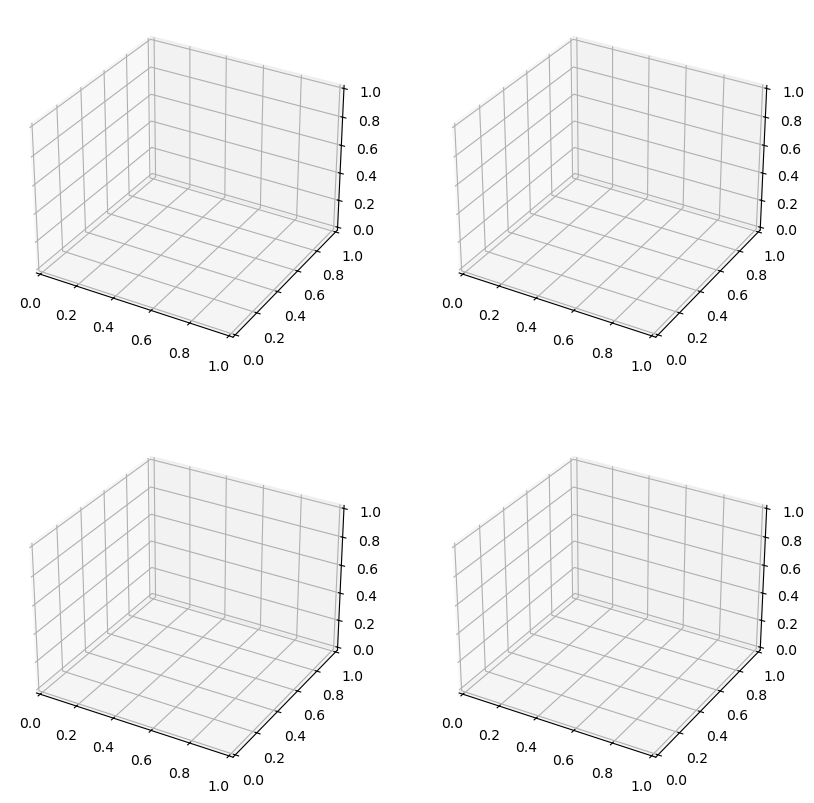

In [38]:
fig = plt.figure(figsize = (10,10))
ax0 = fig.add_subplot(2, 2, 1, projection='3d')
ax1 = fig.add_subplot(2, 2, 2, projection='3d')
ax2 = fig.add_subplot(2, 2, 3, projection='3d')
ax3 = fig.add_subplot(2, 2, 4, projection='3d')
plt.show()

#### **1. What the code does**

* Creates a figure of size 10×10 inches.
* Divides the figure into a 2 × 2 grid (so 4 subplots).
* Adds 4 subplots, each configured for 3D projection.
* Displays the empty layout with `plt.show()`.

The result is a dashboard of 4 blank 3D plots you can later fill with data.

---

#### **2. Code Breakdown**

```python
fig = plt.figure(figsize = (10,10))
```

* Creates a new Matplotlib figure container with width = 10 inches and height = 10 inches.

```python
ax0 = fig.add_subplot(2, 2, 1, projection='3d')
```

* Adds the first subplot.
* The arguments `(2, 2, 1)` mean:

  * 2 rows of subplots.
  * 2 columns of subplots.
  * This is the 1st subplot in row-major order (top-left).
* `projection='3d'` makes this a **3D axes object** instead of a 2D one.

```python
ax1 = fig.add_subplot(2, 2, 2, projection='3d')
```

* Same as above, but the 2nd subplot (top-right).

```python
ax2 = fig.add_subplot(2, 2, 3, projection='3d')
```

* The 3rd subplot (bottom-left).

```python
ax3 = fig.add_subplot(2, 2, 4, projection='3d')
```

* The 4th subplot (bottom-right).

```python
plt.show()
```

* Renders the figure and displays the 4 empty 3D axes.

---

#### **3. Learning Points**

* **`plt.figure` vs. `plt.subplots`:** `plt.figure` gives you an empty container; `plt.subplots` is often easier for grids but doesn’t directly support 3D projections.
* **`add_subplot(rows, cols, index)`:** Classic way to add subplots to a figure.
* **Projection parameter:** `projection='3d'` turns any subplot into a 3D plot.
* Common mistake: forgetting to pass `projection='3d'`, which creates a normal 2D plot instead.

---

**In short:**
This code sets up a **2×2 grid of empty 3D subplots** in a 10×10-inch figure, ready for you to fill with 3D scatter plots, surfaces, or wireframes.


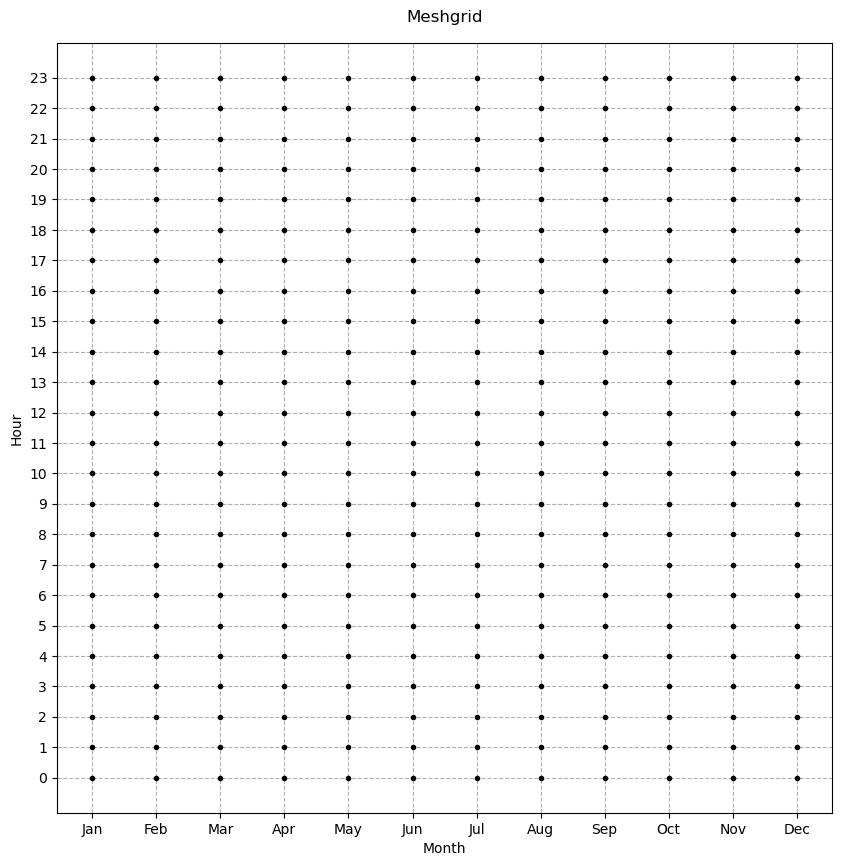

In [39]:
# Print the meshgrid
fig, ax = plt.subplots(figsize = (10,10))
ax.plot(X, Y, marker='.', color='k', linestyle='none')
ax.set( xticks = range(1,13,1), xticklabels = month_names,  xlabel = "Month",
        yticks = range(0,24), yticklabels = range(0,24), ylabel = "Hour")
ax.grid(linestyle = '--')
ax.set_title("Meshgrid",pad = 15)
plt.show()

#### Grid of 3D subplots with `subplots`

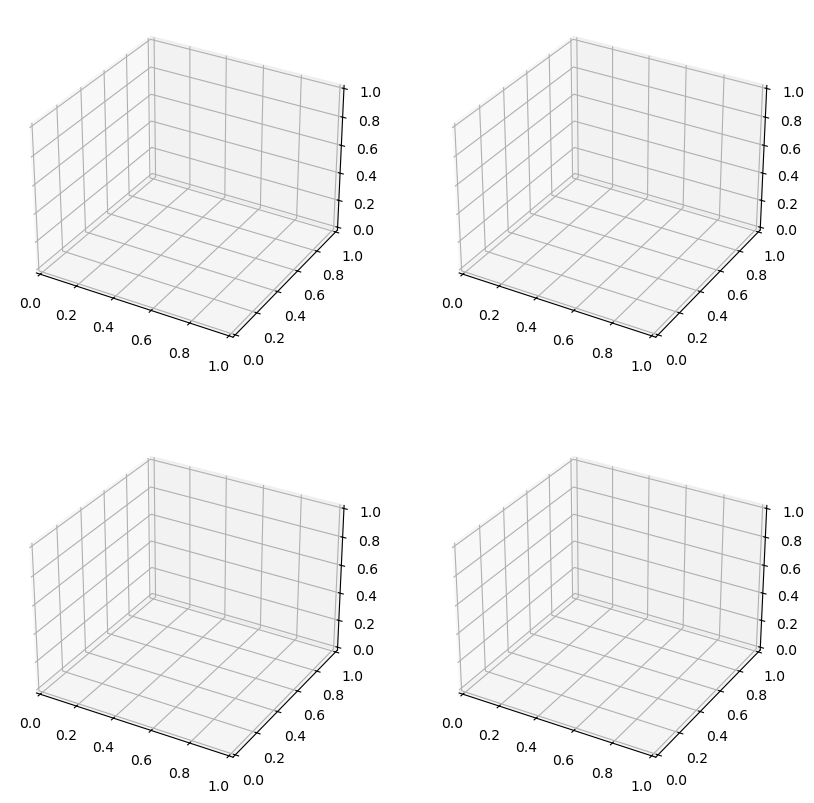

In [40]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(
        figsize = (10,10), 
        nrows =2, 
        ncols = 2, 
        subplot_kw=dict(projection='3d'))
plt.show()

### Grid of 3D subplots with `subplots`: Comparison with `figure` and `add_subplot`

#### **1. First approach (with `fig.add_subplot`)**

```python
fig = plt.figure(figsize = (10,10))
ax0 = fig.add_subplot(2, 2, 1, projection='3d')
ax1 = fig.add_subplot(2, 2, 2, projection='3d')
ax2 = fig.add_subplot(2, 2, 3, projection='3d')
ax3 = fig.add_subplot(2, 2, 4, projection='3d')
plt.show()
```

* **How it works**:

  * Starts with a blank `Figure`.
  * Manually adds each subplot one by one.
  * `(2,2,1)` means "2 rows, 2 columns, 1st slot", and so on.
* **What you get**:

  * Four `Axes3D` objects (`ax0` … `ax3`), each 3D.
* **Pros**:

  * Very explicit control; good if you want to add subplots conditionally or at nonstandard positions.
* **Cons**:

  * Verbose (lots of repeated code).
  * Axes are stored individually, not grouped in a nice array.

---

#### **2. Second approach (with `plt.subplots`)**

```python
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(
    figsize=(10,10),
    nrows=2,
    ncols=2,
    subplot_kw=dict(projection='3d'))
plt.show()
```

* **How it works**:

  * Creates the figure *and* all subplots in one call.
  * `subplot_kw=dict(projection='3d')` applies the 3D setting to **all** subplots at once.
  * Returns `ax` as a 2D NumPy array (shape `[2,2]`).
  * The tuple unpacking `((ax0, ax1), (ax2, ax3))` assigns each subplot to a variable.
* **What you get**:

  * Same 4 `Axes3D` objects, but organized in an array that mirrors the grid layout.
* **Pros**:

  * Shorter, cleaner, and less repetitive.
  * Easier to loop through axes (since `ax` is an array).
* **Cons**:

  * Slightly trickier unpacking if you’re new to Python tuples/arrays.

---

#### **3. Key differences**

| Feature     | `fig.add_subplot`                           | `plt.subplots`                                              |
| ----------- | ------------------------------------------- | ----------------------------------------------------------- |
| Syntax      | Add each subplot individually               | Create grid all at once                                     |
| Control     | Very explicit, one by one                   | Grid-based, cleaner                                         |
| Return type | Individual axes objects                     | Array of axes objects                                       |
| 3D setup    | Must set `projection='3d'` for each subplot | Can apply `subplot_kw=dict(projection='3d')` to all at once |
| Readability | More verbose                                | More concise, easier for multiple subplots                  |

---

#### **4. When to use which**

* Use **`fig.add_subplot`** if:

  * You want to add subplots at unusual positions (like a 2×2 grid but only fill 3 slots).
  * You prefer explicit, step-by-step subplot creation.

* Use **`plt.subplots`** if:

  * You want a full, regular grid.
  * You need to loop over all axes (the array form makes iteration easy).
  * You want concise, clean code.

---

**In short:**
Both snippets produce a 2×2 grid of 3D plots. The first (`add_subplot`) is explicit but repetitive, while the second (`plt.subplots`) is concise, elegant, and easier to scale for grids.


In [41]:
ax0

<Axes3D: >

In [42]:
ax1

<Axes3D: >

In [43]:
ax2

<Axes3D: >

In [44]:
ax3

<Axes3D: >

### 7. Create the first subplot—a 3D wireframe plot
Use the x, y, and z computed in Steps 4 and 5
Use fig.add_subplot() and ax.plot_wireframe() functions.

In [45]:
[param for param in list(plt.rcParams.keys()) if "title" in param]

['axes.titlecolor',
 'axes.titlelocation',
 'axes.titlepad',
 'axes.titlesize',
 'axes.titleweight',
 'axes.titley',
 'figure.titlesize',
 'figure.titleweight',
 'legend.title_fontsize']

In [46]:
plt.rc("axes",  titlesize = 13, titleweight = "light", labelsize = 9)
plt.rc("xtick", labelsize = 8)
plt.rc("ytick", labelsize = 8)

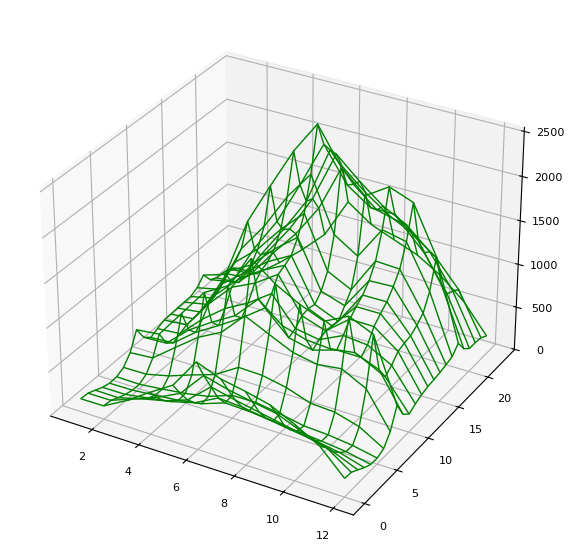

In [47]:
fig, ax = plt.subplots(figsize = (10,7),  
                       subplot_kw = dict(projection='3d'))
ax.plot_wireframe(X, Y, Z, color="green", linewidth = 1)
plt.show()

In [48]:
SeptG = [9]
Xsep, Ysep = np.meshgrid(SeptG, bikes_grid.index)

In [49]:
Xsep.shape

(24, 1)

In [50]:
Ysep.shape

(24, 1)

In [51]:
Zsep = Z[:,8]
Zsep

array([ 763,  592,  395,  265,  176,  165,  353,  726, 1145,  765,  683,
        781,  900,  976, 1042, 1141, 1300, 1591, 2010, 1644, 1486, 1398,
       1236,  921])

In [52]:
Zsep = Zsep.reshape(24,1)
Zsep

array([[ 763],
       [ 592],
       [ 395],
       [ 265],
       [ 176],
       [ 165],
       [ 353],
       [ 726],
       [1145],
       [ 765],
       [ 683],
       [ 781],
       [ 900],
       [ 976],
       [1042],
       [1141],
       [1300],
       [1591],
       [2010],
       [1644],
       [1486],
       [1398],
       [1236],
       [ 921]])

In [53]:
Zsep.shape

(24, 1)

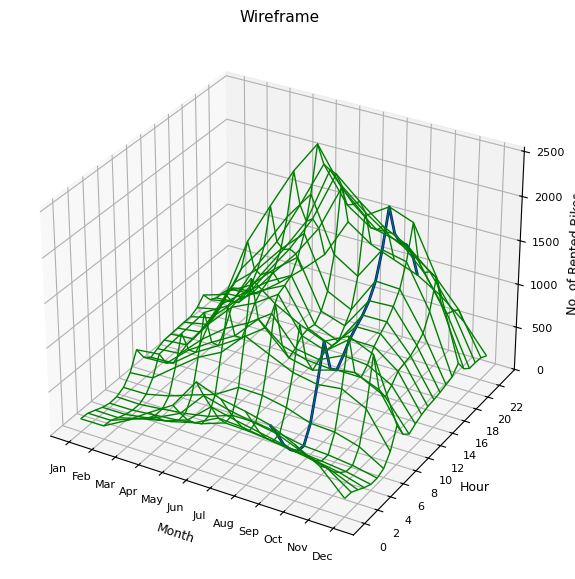

In [54]:
fig, ax = plt.subplots(figsize = (10,7),  
                       subplot_kw=dict(projection='3d'))
ax.plot_wireframe(X, Y, Z, color="green", linewidth = 1)
ax.set( xticks = range(1,13,1), xticklabels = month_names,  
           xlabel = "Month",
        yticks = range(0,24,2), yticklabels = range(0,24,2), 
           ylabel = "Hour",
        zlabel = "No. of Rented Bikes",
)
ax.plot_wireframe(Xsep, Ysep, Zsep, color = "blue", 
                  linewidth =2)
ax.set_title(label = "Wireframe", fontsize = 11)
fig.savefig(img_loc+"Wireframe_with_line.png" , dpi = 400)
plt.show()

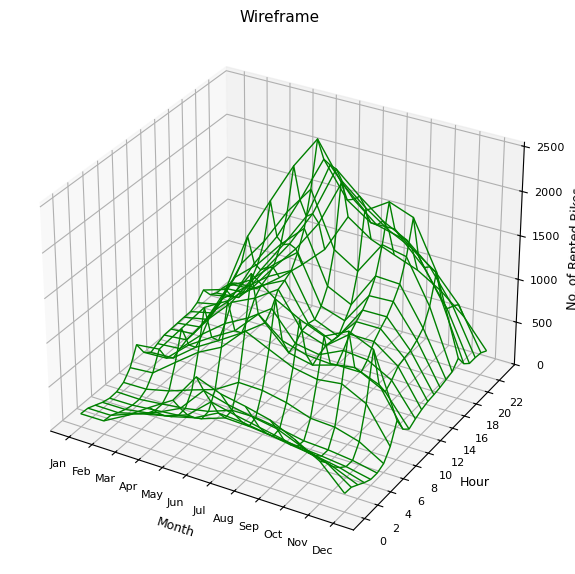

In [55]:
fig, ax = plt.subplots(figsize = (10,7),  
                       subplot_kw=dict(projection='3d'))
ax.plot_wireframe(X, Y, Z, color="green", linewidth = 1)
ax.set( xticks = range(1,13,1), xticklabels = month_names,  
           xlabel = "Month",
        yticks = range(0,24,2), yticklabels = range(0,24,2), 
           ylabel = "Hour",
        zlabel = "No. of Rented Bikes",
)
ax.set_title(label = "Wireframe", fontsize = 11, pad =0)
fig.savefig(img_loc+"Wireframe.png" , dpi = 400)
plt.show()

#### Wireframe

#### **1. Plot Overview**

* This is a **3D wireframe plot**, which is like draping a mesh grid over your data surface.
* The **x-axis** represents the months, the **y-axis** represents the hours of the day, and the **z-axis** shows the average number of bikes rented.
* The lines of the wireframe help you see the "shape" of the data across time.
* You can read it by looking at peaks (where the wireframe rises up high on the z-axis) and valleys (where it dips low).

This visualization helps answer:

* *At which months and hours are bike rentals the highest?*
* *Do we see daily peaks (like commuting hours) repeating across months?*
* *How does rental demand vary seasonally and hourly at the same time?*

---

#### **2. Code Breakdown**

```python
fig, ax = plt.subplots(figsize=(10,7), subplot_kw=dict(projection='3d'))
```

* Creates a figure (`fig`) with one subplot (`ax`).
* `figsize=(10,7)` makes the plot larger (10 inches by 7 inches).
* `subplot_kw=dict(projection='3d')` tells Matplotlib to make a 3D plot.

```python
ax.plot_wireframe(X, Y, Z, color="green", linewidth=1)
```

* `X, Y` are the coordinate grids you created with `np.meshgrid` (months and hours).
* `Z` is the pivot table of average rentals.
* `plot_wireframe` draws a mesh across all those coordinates.
* `color="green"` → wireframe is green.
* `linewidth=1` → the lines are thin, so the structure is clear without being too heavy.

```python
plt.show()
```

* Displays the final wireframe plot.

---

#### **3. Questions for Reflecting on Visual Elements**

* What do you notice about the z-axis scale — where do the highest peaks in rentals occur?

---

#### **4. Data Interpretation: Explore these questions to deepen your understanding**

* At which hours of the day do you see the highest peaks, and do these peaks repeat across months?
* Do some months appear consistently higher in rentals, suggesting seasonal patterns?
* Are there flat regions where rentals stay low regardless of the hour?

---

#### **5. Learning Points**

* **Key Matplotlib concepts:**

  * How to use `plot_wireframe` for 3D surface visualization.
  * The role of `np.meshgrid` in preparing X and Y grids.
  * Customizing colors and line widths for readability.
* **When to use this plot:**

  * To show how a variable (bike rentals) changes across two independent dimensions (hour and month).
  * It’s most useful for showing general "shape" and patterns in the data.
* **Common student mistakes:**

  * Forgetting to create `X, Y` grids with `meshgrid`, leading to dimension mismatch errors.
  * Using too thick a line width, which makes the mesh look cluttered.
  * Not labeling axes, which makes it hard to interpret.

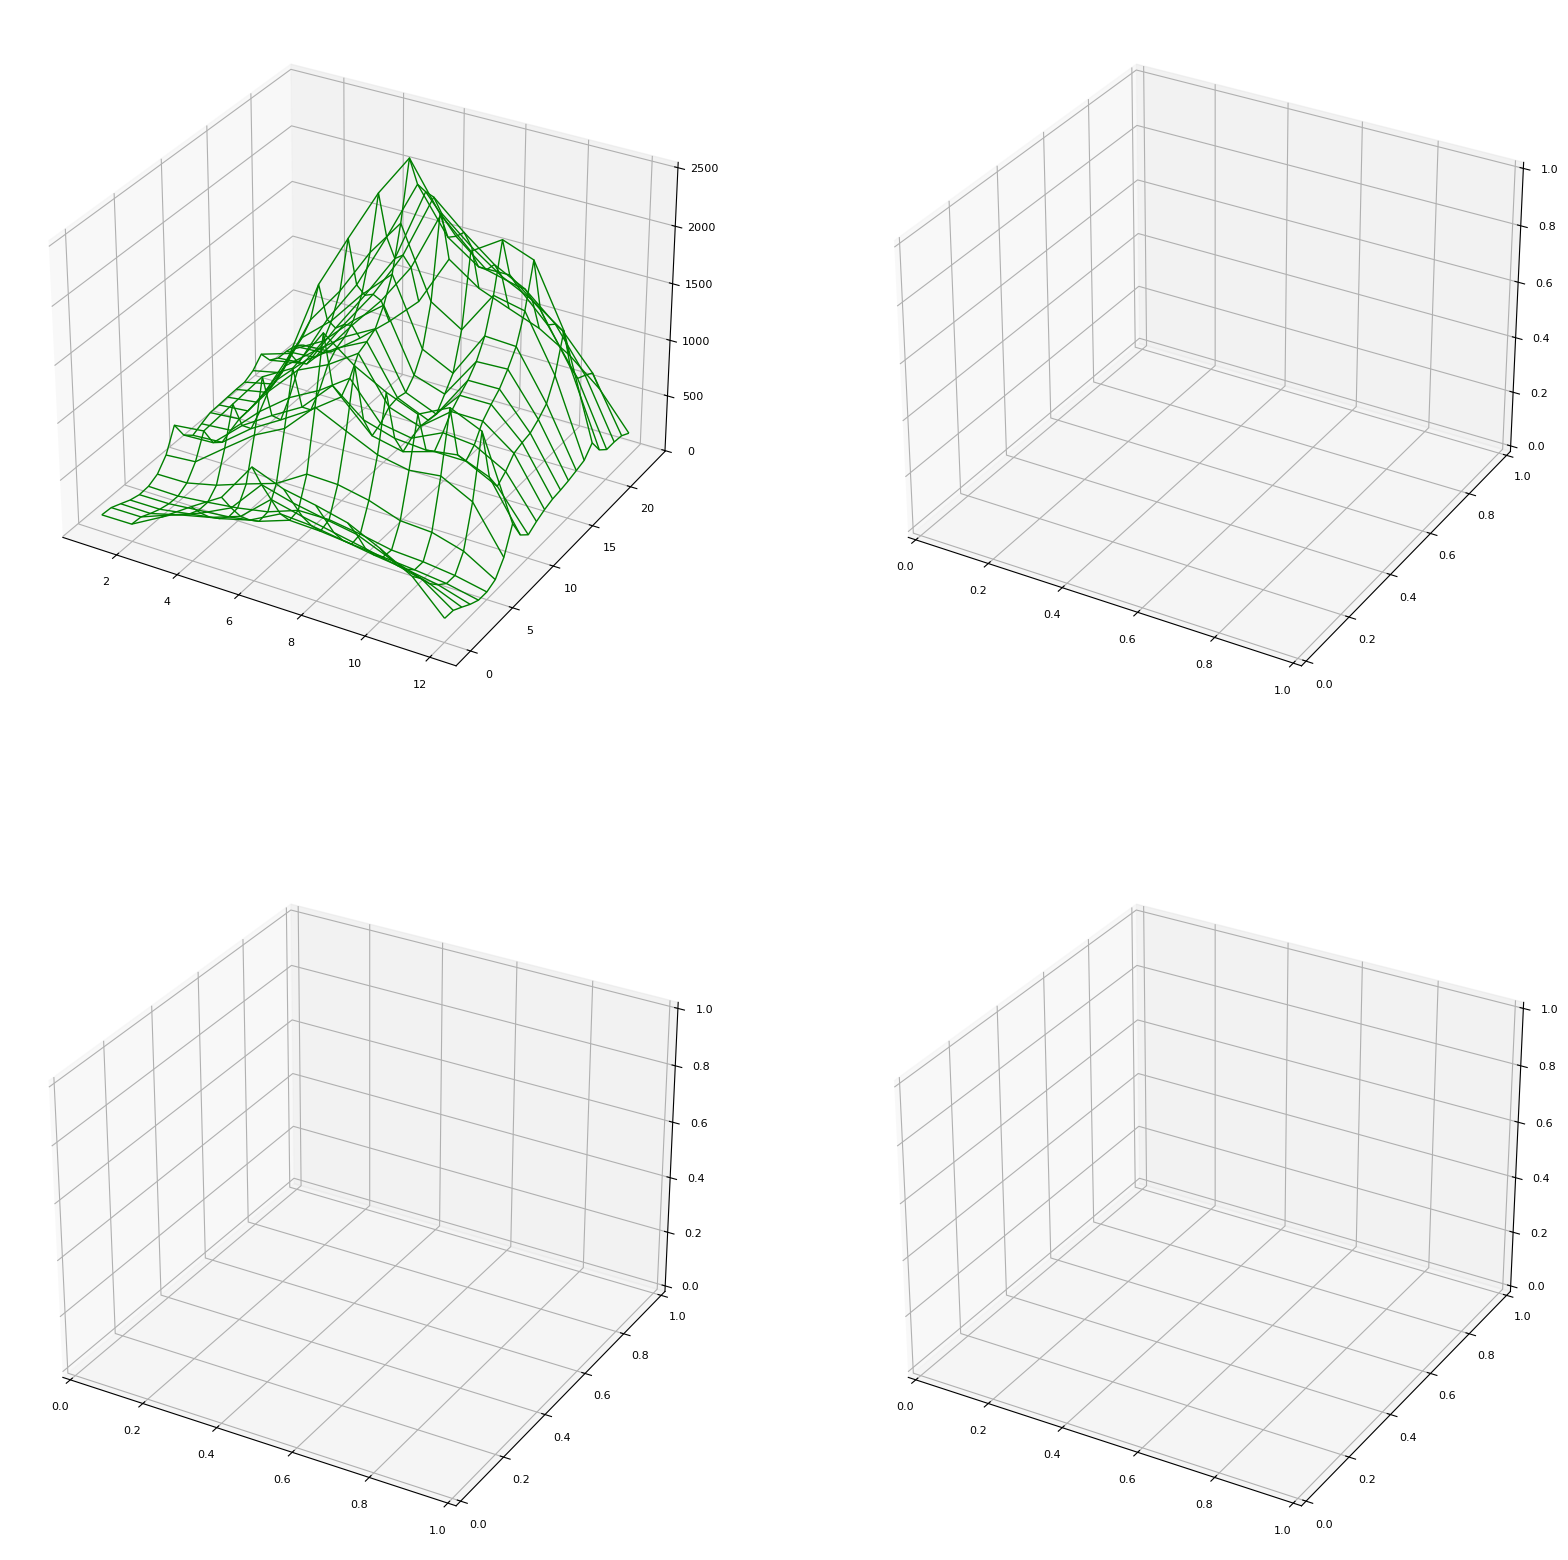

In [56]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(
        figsize = (20,20), nrows =2, ncols = 2, subplot_kw=dict(projection='3d'))
ax0.plot_wireframe(X, Y, Z, color="green", linewidth = 1)

plt.show()

### 8. Set the ticks, tick labels, axes labels, and plot title for the subplot 
- x-axis shows month names.
- y-axis shows hours.
- You can retain default ticks for the z-axis that shows mean number of bikes.

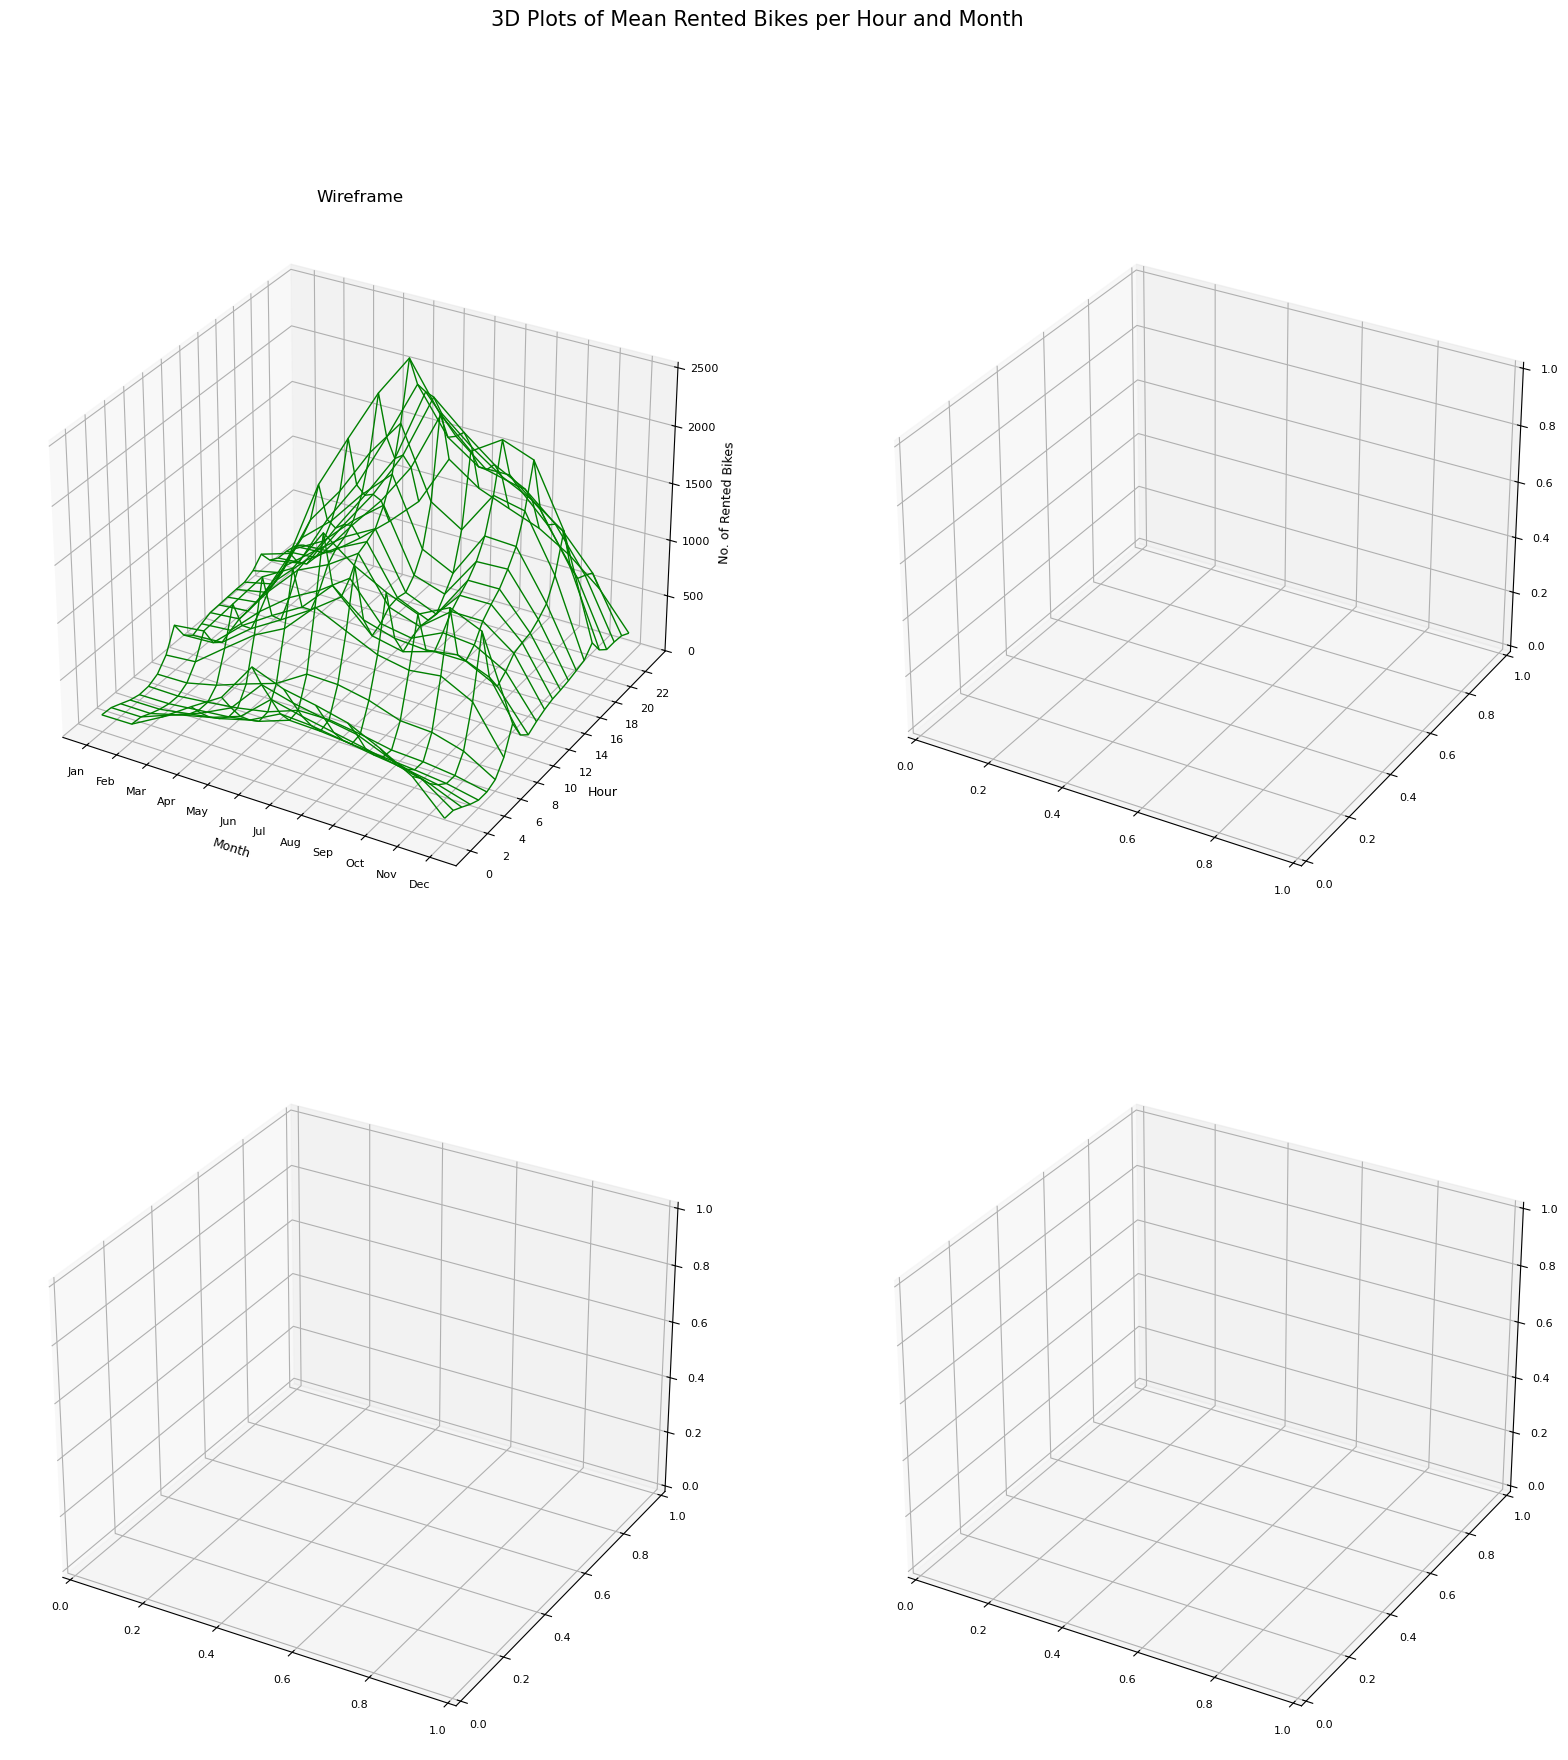

In [57]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(
        figsize = (20,20), nrows =2, ncols = 2, 
    subplot_kw=dict(projection='3d'))
fig.suptitle('3D Plots of Mean Rented Bikes per Hour and Month', 
             fontsize = 15)

ax0.plot_wireframe(X, Y, Z, color="green", linewidth = 1)
ax0.set(xticks = range(1,13,1), xticklabels = month_names,  
            xlabel = "Month",
        yticks = range(0,24,2), yticklabels = range(0,24,2), 
            ylabel = "Hour",
        zlabel = "No. of Rented Bikes",
)
ax0.set_title(label = "Wireframe", fontsize = 12)

plt.show()

### 9. Create and decorate the second subplot—a rotated view of the 3D wireframe plot created in Step 7
- Use ax.plot_wireframe(x, y, z, color='green').
- Set the rotation parameters for your plot using ax.view_init(20, 45).
- This sets elevation = 20 degrees and azimuth = 45 degrees for the rotated view.
- Decorate the axes of your plot like in Step 8.

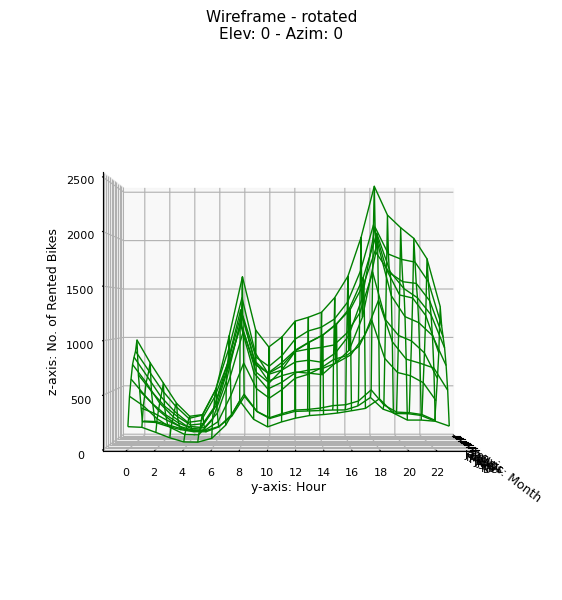

In [58]:
fig, ax = plt.subplots(figsize = (7,7),  subplot_kw=dict(projection='3d'))
ax.plot_wireframe(X, Y, Z, color="green", linewidth = 1)
ax.set( xticks = range(1,13,1), xticklabels = month_names,  xlabel = "x-axis: Month",
        yticks = range(0,24,2), yticklabels = range(0,24,2), ylabel = "y-axis: Hour",
        zlabel = "z-axis: No. of Rented Bikes",
)
ax.view_init(elev = 0, azim= 0)
ax.set_title(label = f"Wireframe - rotated\nElev: {0} - Azim: {0}", fontsize = 11 )
plt.subplots_adjust(top=0.9, wspace = 0.1)
plt.show()


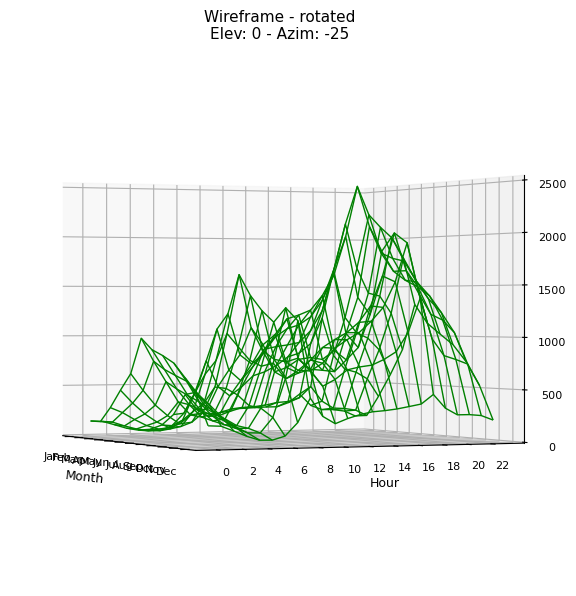

In [59]:
fig, ax = plt.subplots(figsize = (10,7),  
                       subplot_kw=dict(projection='3d'))
ax.plot_wireframe(X, Y, Z, color="green", linewidth = 1)
ax.set( xticks = range(1,13,1), xticklabels = month_names,  
           xlabel = "Month",
        yticks = range(0,24,2), yticklabels = range(0,24,2), 
           ylabel = "Hour",
        zlabel = "No. of Rented Bikes",
)

elev = 0
azim = -25
ax.view_init(elev = elev, azim= azim)
plot_title = f"Wireframe - rotated\nElev: {elev} - Azim: {azim}"
ax.set_title(label = plot_title, fontsize = 11)

plt.show()

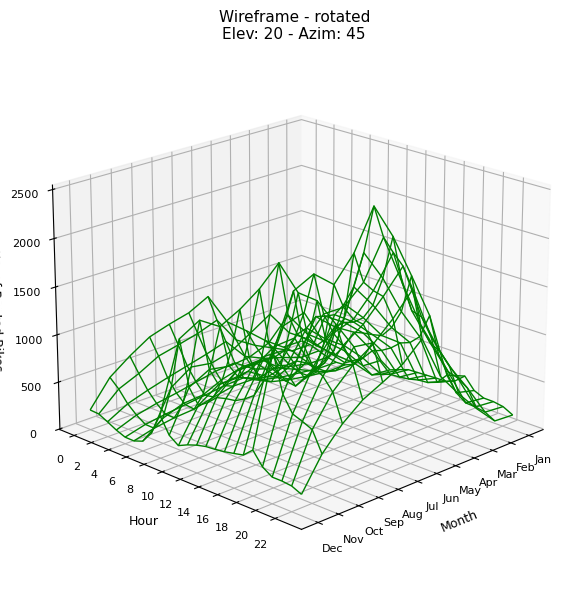

In [60]:
fig, ax = plt.subplots(figsize = (10,7),  
                       subplot_kw=dict(projection='3d'))
ax.plot_wireframe(X, Y, Z, color="green", linewidth = 1)
ax.set( xticks = range(1,13,1), xticklabels = month_names,  
           xlabel = "Month",
        yticks = range(0,24,2), yticklabels = range(0,24,2), 
           ylabel = "Hour",
        zlabel = "No. of Rented Bikes",
)

elev = 20
azim = 45
ax.view_init(elev = elev, azim= azim)
plot_title = f"Wireframe - rotated\nElev: {elev} - Azim: {azim}"
ax.set_title(label = plot_title, fontsize = 11)
fig.savefig(img_loc+"Wireframe_rotated.png" , dpi = 400)
plt.show()

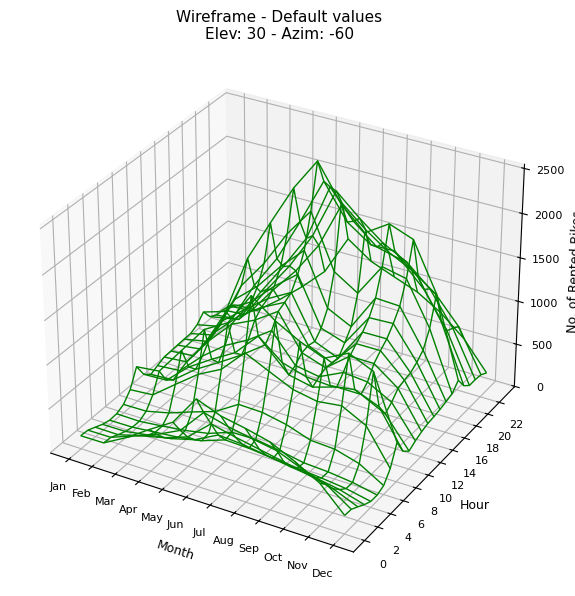

In [61]:
fig, ax = plt.subplots(figsize = (10,7),  subplot_kw=dict(projection='3d'))
ax.plot_wireframe(X, Y, Z, color="green", linewidth = 1)
ax.set( xticks = range(1,13,1), xticklabels = month_names,  xlabel = "Month",
        yticks = range(0,24,2), yticklabels = range(0,24,2), ylabel = "Hour",
        zlabel = "No. of Rented Bikes",
)
ax.set_title(label = f"Wireframe - Default values\nElev: {30} - Azim: {-60}", fontsize = 11)
plt.show()

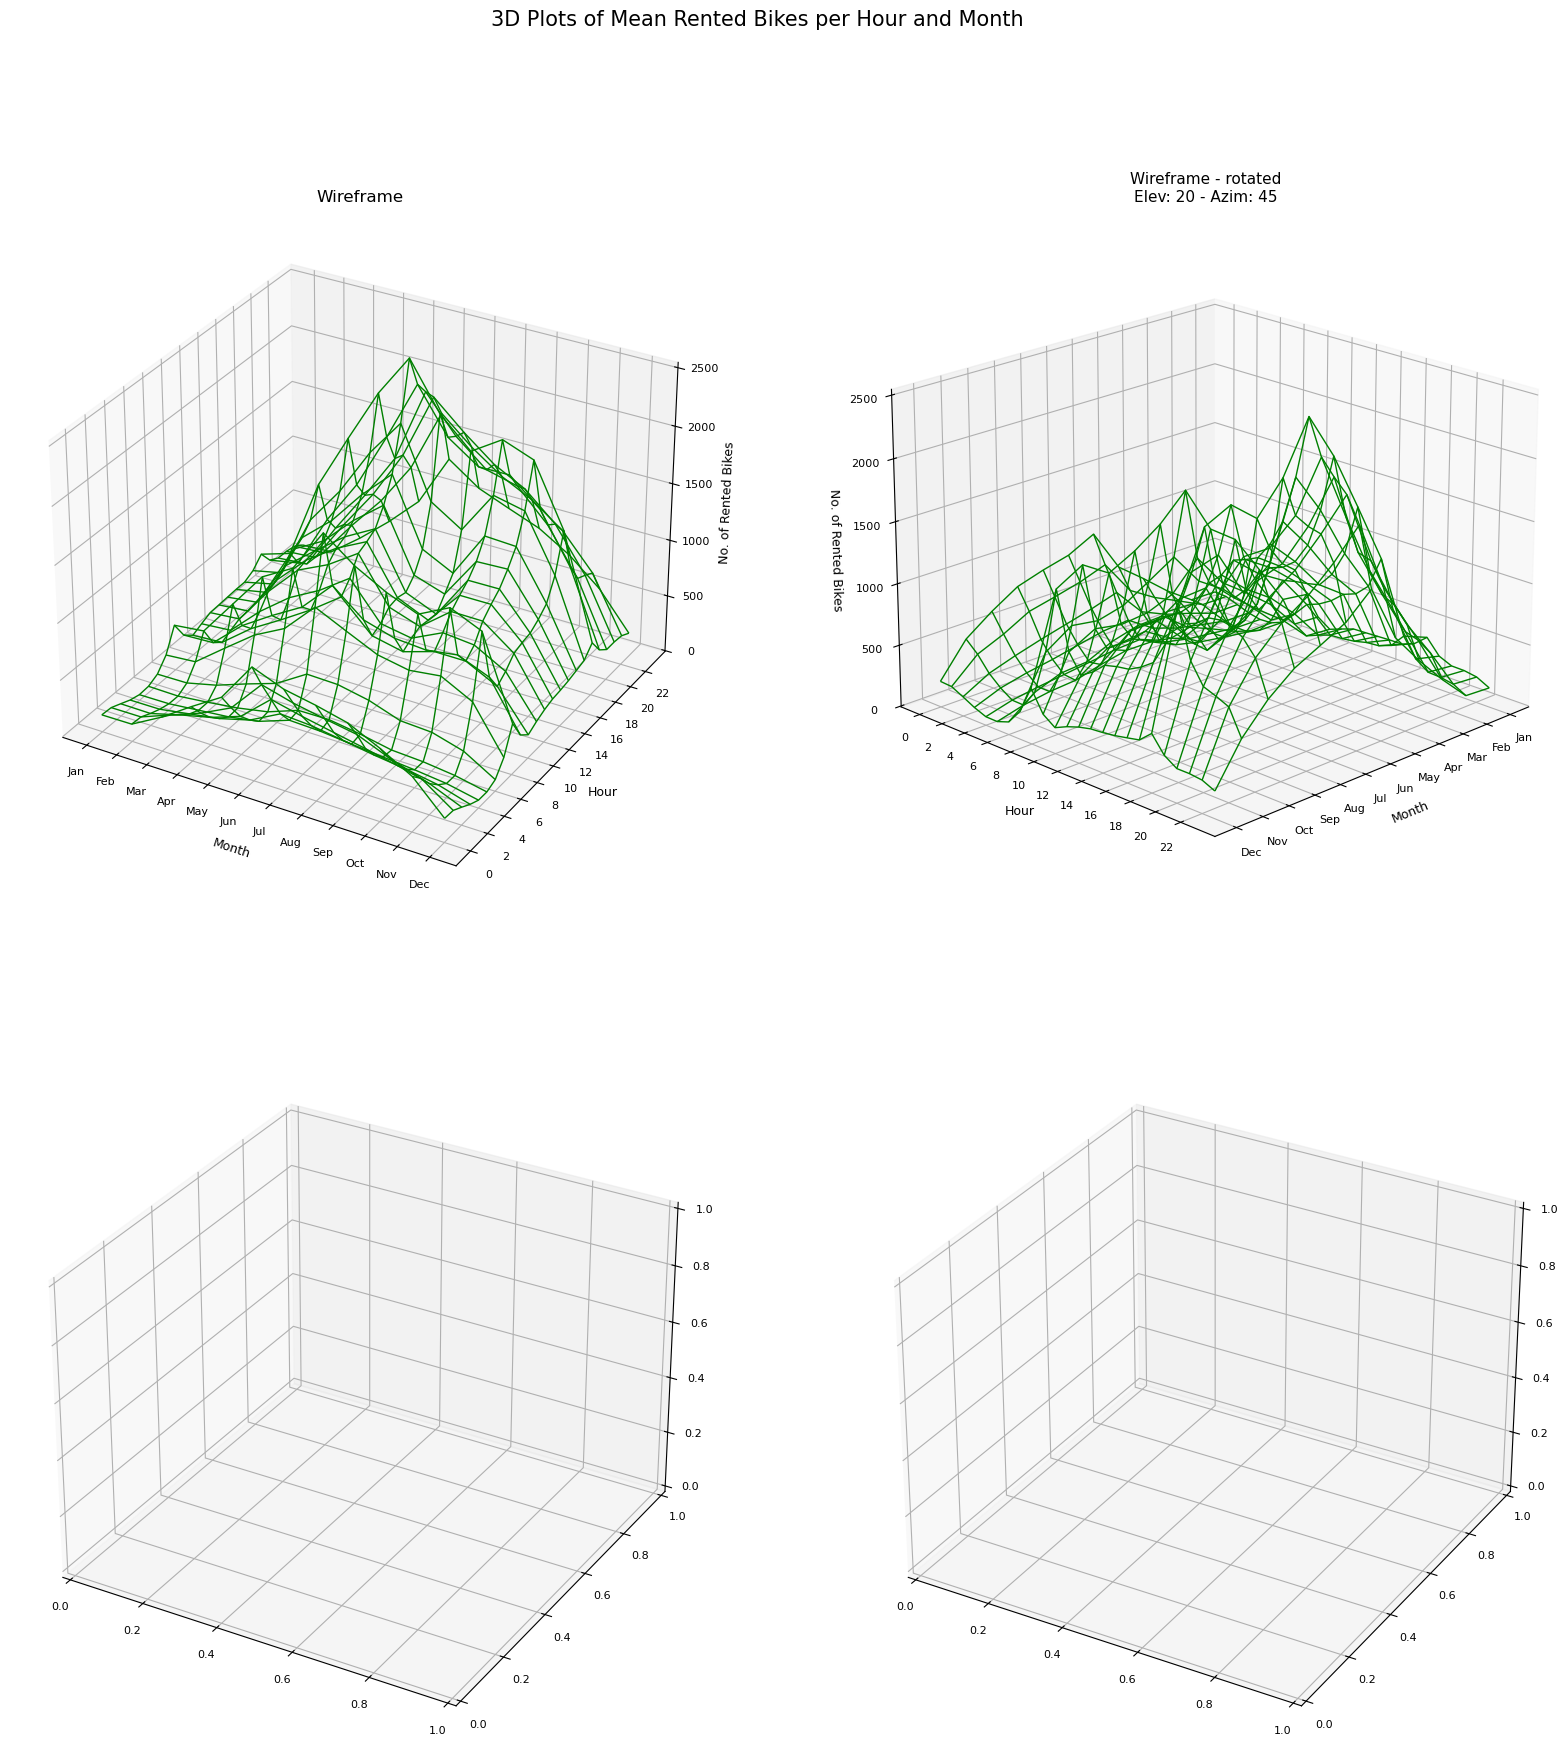

In [62]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(figsize = (20,20), 
        nrows =2, ncols = 2, subplot_kw=dict(projection='3d'))
fig.suptitle('3D Plots of Mean Rented Bikes per Hour and Month', 
             fontsize = 15)

ax0.plot_wireframe(X, Y, Z, color="green", linewidth = 1)
ax0.set(xticks = range(1,13,1), xticklabels = month_names, xlabel = "Month",
        yticks = range(0,24,2), yticklabels = range(0,24,2), ylabel = "Hour",
        zlabel = "No. of Rented Bikes",
)
ax0.set_title(label = 'Wireframe', fontsize = 12)

ax1.plot_wireframe(X, Y, Z, color="green", linewidth = 1)
ax1.set(xticks = range(1,13,1), xticklabels = month_names, xlabel = "Month",
        yticks = range(0,24,2), yticklabels = range(0,24,2), ylabel = "Hour",
        zlabel = "No. of Rented Bikes")
elev = 20
azim = 45
ax1.view_init(elev = elev, azim = azim)
ax1_title = f"Wireframe - rotated\nElev: {elev} - Azim: {azim}"
ax1.set_title(label = ax1_title, fontsize = 11)

plt.show()

### 10. Create and decorate the third subplot—a 3D contour plot using x, y, and z computed in Steps 4 and 5.

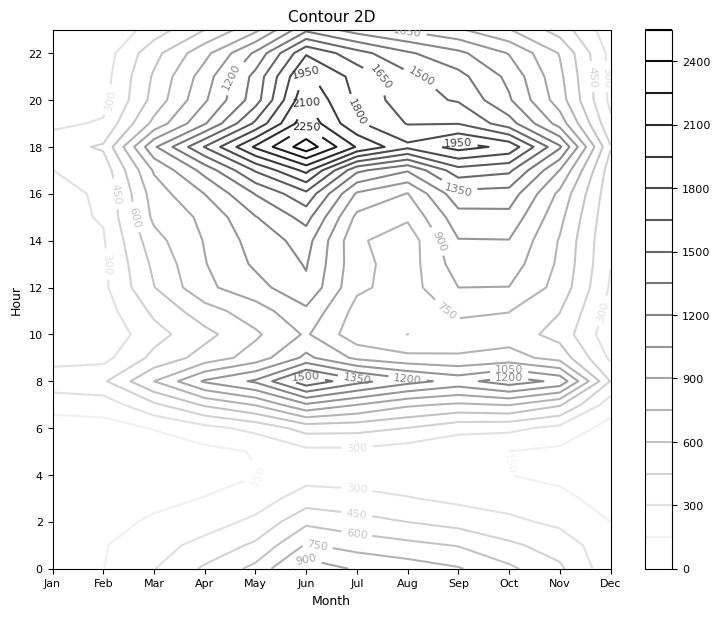

In [63]:
fig, ax = plt.subplots(figsize = (9,7))

contour_plot = ax.contour(X, Y, Z, levels = 20, cmap='binary')

ax.set(xticks = range(1,13,1), xticklabels = month_names,  
       xlabel = "Month",
       yticks = range(0,24,2), yticklabels = range(0,24,2), 
       ylabel = "Hour")
ax.set_title(label = "Contour 2D", fontsize = 11)

plt.colorbar(contour_plot, ax = ax)
plt.clabel(contour_plot, inline = True, fontsize =8)
fig.savefig(img_loc+"Contour_2D.png" , dpi = 400)
plt.show()

### Contour 2D Plot

#### 1. Plot Overview

This is a **2D contour plot**.

* It shows how the number of bikes rented (Z values) varies across two independent variables: month (X-axis) and hour of the day (Y-axis).
* Contour lines connect points with the same Z value (like elevation lines on a topographic map).
* This helps answer: *At what times of day and in which months do bike rentals tend to be higher or lower?*

---

#### 2. Code Breakdown

```python
fig, ax = plt.subplots(figsize = (9,7))
```

* Creates a figure (`fig`) and a set of axes (`ax`).
* `figsize=(9,7)` makes the plot wide enough to show months and tall enough for 24 hourly ticks.

```python
contour_plot = ax.contour(X, Y, Z, levels = 20, cmap='binary')
```

* `ax.contour()` draws contour lines.
* `X, Y, Z` are the meshgrid values: months (X), hours (Y), and rentals (Z).
* `levels=20` means the Z values are split into 20 equally spaced contour intervals.
* `cmap='binary'` gives a grayscale look, from light to dark.

```python
ax.set(xticks = range(1,13,1), xticklabels = month_names,  
       xlabel = "Month",
       yticks = range(0,24,2), yticklabels = range(0,24,2), 
       ylabel = "Hour")
```

* Customizes axis ticks:

  * X-axis: 1–12 replaced with short month names (`month_names`).
  * Y-axis: ticks every 2 hours from 0 to 24.
* Labels the axes.

```python
ax.set_title(label = "Contour 2D", fontsize = 11)
```

* Sets the plot’s title.

```python
plt.colorbar(contour_plot, ax = ax)
```

* Adds a colorbar showing the scale of bike rentals (darker/lighter regions).

```python
plt.clabel(contour_plot, inline = True, fontsize =8)
```

* Labels some contour lines directly with their numeric values.
* `inline=True` makes labels fit into the lines nicely.

```python
fig.savefig(img_loc+"Contour_2D.png" , dpi = 400)
plt.show()
```

* Saves a high-resolution image.
* Displays the plot.

---

#### 3. Questions for Reflecting on Visual Elements

* What do you notice about the spacing of the contour lines — are they closer together in some areas?
* How would you describe the role of the colorbar in helping interpret the Z values?

---

#### 4. Data Interpretation: Explore these questions to deepen your understanding

* At what times of day do we see the densest contours, suggesting rapid changes in bike rentals?
* Do certain months show more consistent (flatter) patterns across hours?
* What insights can you gain by comparing winter months vs. summer months?
* Does the plot make it easy to identify peaks and valleys in rentals, or would another plot (like a surface plot) be clearer?

---

#### 5. Learning Points

* **Concepts shown**: contour plotting, colorbars, labeling lines, customizing ticks.
* **When appropriate**: when you want to show how a third variable varies across two continuous predictors.
* **Common mistakes**: too few/many levels (hard to read), missing axis labels, or not adding a colorbar.


#### Colored Contour in 2D

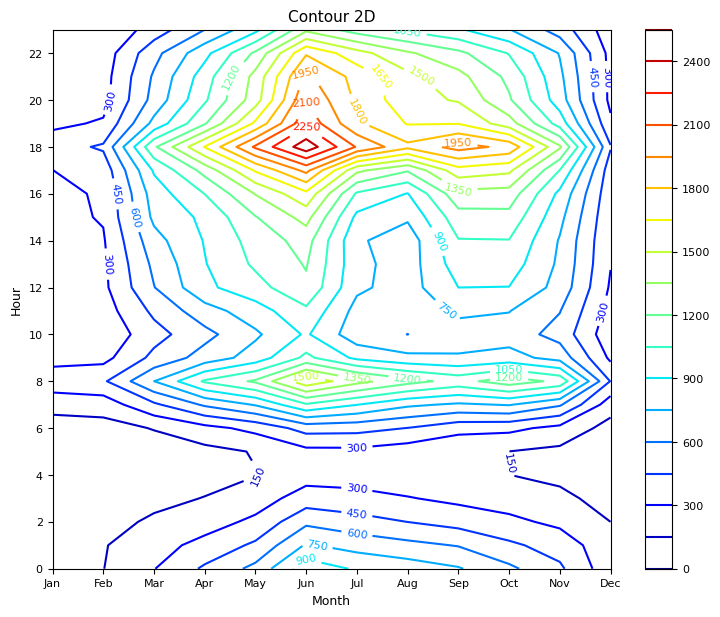

In [64]:
fig, ax = plt.subplots(figsize = (9,7))
contour_plot = ax.contour(X, Y, Z, levels = 20, cmap='jet')
ax.set(xticks = range(1,13,1), xticklabels = month_names,  
       xlabel = "Month",
       yticks = range(0,24,2), yticklabels = range(0,24,2), 
       ylabel = "Hour")
ax.set_title(label = "Contour 2D", fontsize = 11)
fig.colorbar(contour_plot, ax = ax)
ax.clabel(contour_plot, inline = True, fontsize =8)
fig.savefig(img_loc+"Colored_Contour_2D.png" , dpi = 400)
plt.show()

In [65]:
X

array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 1,  2,  3,  4,  5,  6,

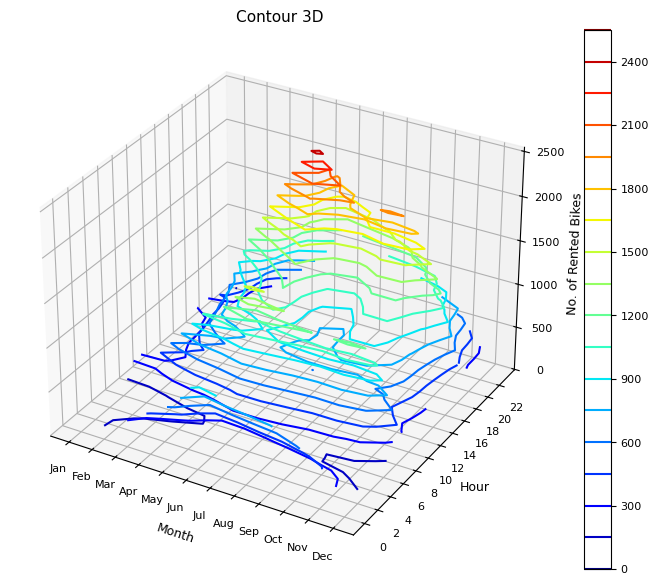

In [66]:
fig, ax = plt.subplots(figsize = (9,7), 
                       subplot_kw=dict(projection='3d'))
contour_plot = ax.contour(X, Y, Z, levels = 20, cmap='jet')
ax.set(xticks = range(1,13,1), xticklabels = month_names,  
       xlabel = "Month",
       yticks = range(0,24,2), yticklabels = range(0,24,2), 
       ylabel = "Hour",
       zlabel = "No. of Rented Bikes")
ax.set_title(label = "Contour 3D", fontsize = 11)
fig.colorbar(contour_plot, ax = ax)

plt.show()

#### Contour 3D

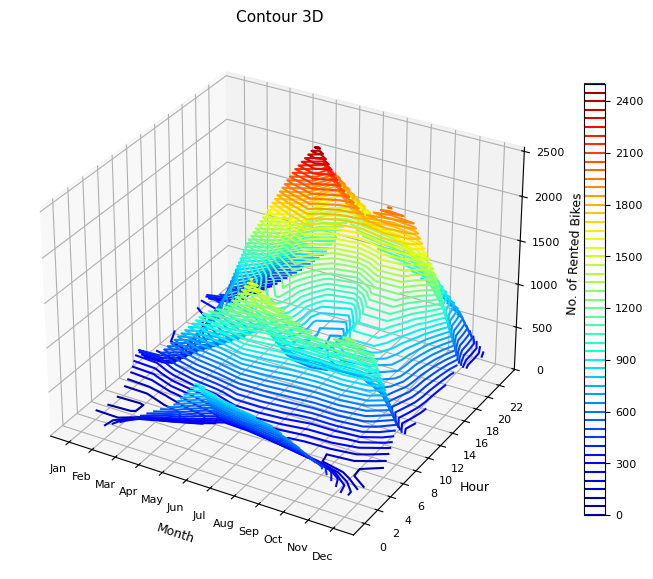

In [67]:
fig, ax = plt.subplots(figsize = (9,7), subplot_kw=dict(projection='3d'))
contour_plot = ax.contour(X, Y, Z, levels = 50, cmap='jet')
ax.set(xticks = range(1,13,1), xticklabels = month_names,  xlabel = "Month",
       yticks = range(0,24,2), yticklabels = range(0,24,2), ylabel = "Hour",
       zlabel = "No. of Rented Bikes")
ax.set_title(label = "Contour 3D", fontsize = 11)
fig.colorbar(contour_plot, ax = ax, shrink = 0.8)
fig.savefig(img_loc+"Colored_Contour_3D.png" , dpi = 400)
plt.show()

### Contour 3D Plot

#### 1. Plot Overview

This is a **3D contour plot**.

* Instead of showing contour lines on a flat plane (2D), the lines are drawn in three dimensions, with the Z-axis representing the average bike rentals.
* It allows you to see the “shape” of the data, almost like a 3D mountain range.
* This plot helps answer: *How do bike rentals vary simultaneously by month and hour?* It adds depth that can highlight peaks (busy rental times) and valleys (quiet times).

---

#### 2. Code Breakdown

```python
fig, ax = plt.subplots(figsize = (9,7), subplot_kw=dict(projection='3d'))
```

* Creates a figure and a 3D Axes object.
* `subplot_kw=dict(projection='3d')` activates Matplotlib’s 3D plotting toolkit.

```python
contour_plot = ax.contour(X, Y, Z, levels = 50, cmap='jet')
```

* Plots 3D contour lines.
* `X, Y, Z`: meshgrid data (months, hours, rentals).
* `levels=50`: increases contour resolution, making smoother patterns.
* `cmap='jet'`: rainbow color map (blue = low rentals, red = high rentals).

```python
ax.set(xticks = range(1,13,1), xticklabels = month_names,  xlabel = "Month",
       yticks = range(0,24,2), yticklabels = range(0,24,2), ylabel = "Hour",
       zlabel = "No. of Rented Bikes")
```

* Customizes axes:

  * **X-axis**: months labeled with names.
  * **Y-axis**: hourly ticks every 2 hours.
  * **Z-axis**: labeled with average number of bikes rented.

```python
ax.set_title(label = "Contour 3D", fontsize = 11)
```

* Sets the title of the plot.

```python
fig.colorbar(contour_plot, ax = ax, shrink = 0.8)
```

* Adds a colorbar to map colors → rental values.
* `shrink=0.8` makes it slightly smaller to fit well with the 3D figure.

```python
fig.savefig(img_loc+"Colored_Contour_3D.png" , dpi = 400)
plt.show()
```

* Saves the figure as high-resolution PNG.
* Displays the plot.

---

#### 3. Questions for Reflecting on Visual Elements

* What do you notice about how the rainbow colormap (`jet`) makes the peaks stand out?
* Does the grid and 3D perspective make the data easier or harder to read compared to the 2D contour plot?
* How does the placement of the colorbar influence readability?

---

#### 4. Data Interpretation: Explore these questions to deepen your understanding

* At which months and hours do the peaks (red zones) occur?
* Are there valleys (blue zones) that correspond to winter nights or off-peak times?
* How does the shape of the “surface” compare across months — do some months have consistently higher rentals throughout the day?
* Does this 3D view help you detect patterns more easily, or would a heatmap/2D contour be clearer for interpretation?

---

#### 5. Learning Points

* **Concepts shown**: creating 3D axes, 3D contour plotting, customizing ticks, adding colorbars.
* **When appropriate**: when you want to show variation of a third variable (Z) across two dimensions in a visually rich way.
* **Common mistakes**: too many contour levels → clutter, rainbow colormap can distort perception, awkward viewing angles can obscure insights.
* **Suggestion for improvement**: Consider rotating the 3D view (`ax.view_init`) to highlight peaks/valleys better, or using a perceptually uniform colormap (like *viridis*) for accessibility.


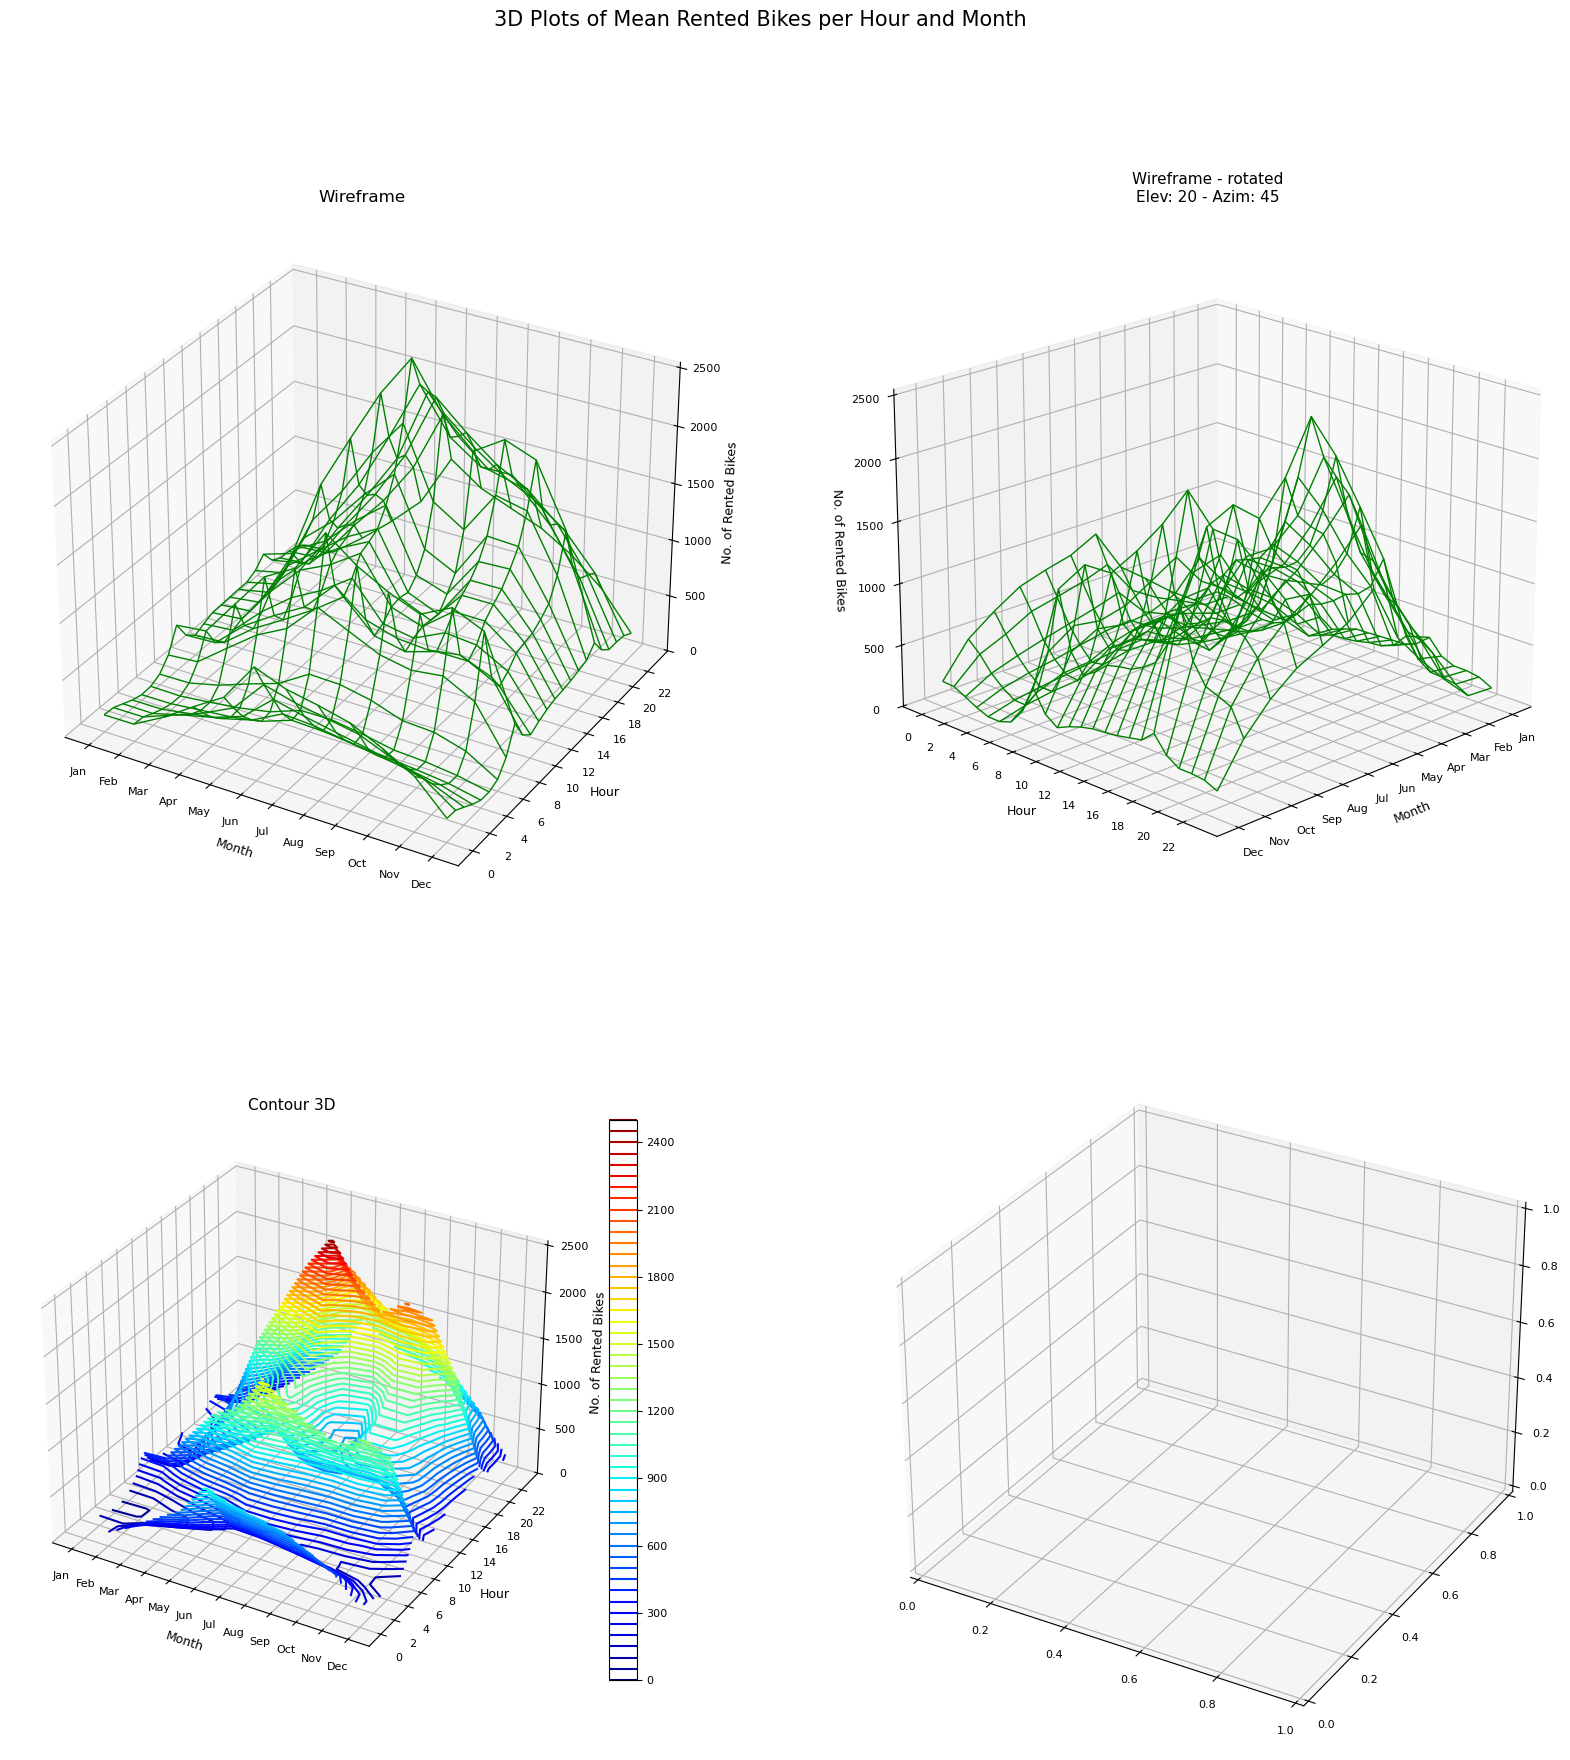

In [68]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(figsize = (20,20), 
        nrows =2, ncols = 2, subplot_kw=dict(projection='3d'))
fig.suptitle('3D Plots of Mean Rented Bikes per Hour and Month', 
             fontsize = 15)

ax0.plot_wireframe(X, Y, Z, color="green", linewidth = 1)
ax0.set(xticks = range(1,13,1), xticklabels = month_names, xlabel = "Month",
        yticks = range(0,24,2), yticklabels = range(0,24,2), ylabel = "Hour",
        zlabel = "No. of Rented Bikes",
)
ax0.set_title(label = 'Wireframe', fontsize = 12)

ax1.plot_wireframe(X, Y, Z, color="green", linewidth = 1)
ax1.set(xticks = range(1,13,1), xticklabels = month_names, xlabel = "Month",
        yticks = range(0,24,2), yticklabels = range(0,24,2), ylabel = "Hour",
        zlabel = "No. of Rented Bikes")
elev = 20
azim = 45
ax1.view_init(elev = elev, azim = azim)
ax1_title = f"Wireframe - rotated\nElev: {elev} - Azim: {azim}"
ax1.set_title(label = ax1_title, fontsize = 11)

contour_plot = ax2.contour(X, Y, Z, levels = 50, cmap='jet')
ax2.set(xticks = range(1,13,1), xticklabels = month_names,  xlabel = "Month",
       yticks = range(0,24,2), yticklabels = range(0,24,2), ylabel = "Hour",
       zlabel = "No. of Rented Bikes")
ax2.set_title(label = "Contour 3D", fontsize = 11)
fig.colorbar(contour_plot, ax = ax2, shrink = 0.8)

plt.show()

### 11. Create and decorate the fourth subplot—a 3D surface plot using x, y, and z computed in Steps 4 and 5.

### 12. Save your plots as a png file with a resolution of 300 dpi

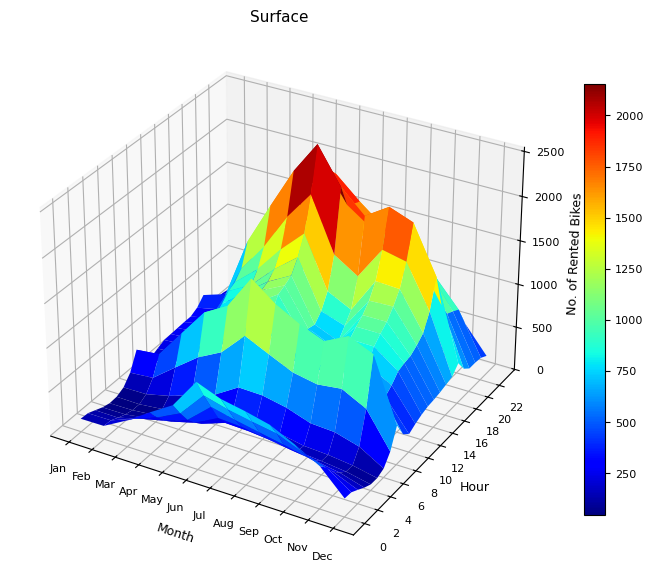

In [69]:
fig, ax = plt.subplots(figsize = (9,7), 
                       subplot_kw=dict(projection='3d'))
surface_plot = ax.plot_surface(X, Y, Z, cmap='jet')
ax.set(xticks = range(1,13,1), xticklabels = month_names,  
       xlabel = "Month",
       yticks = range(0,24,2), yticklabels = range(0,24,2), 
       ylabel = "Hour",
       zlabel = "No. of Rented Bikes")
ax.set_title(label = "Surface", fontsize = 11)
fig.colorbar(surface_plot, ax = ax, shrink = 0.8)
fig.savefig(img_loc+"Surface.png" , dpi = 400)
plt.show()

### Surface Plot

#### 1. Plot Overview

This is a **3D surface plot**.

* It creates a continuous, colored surface to represent how bike rentals (Z-axis) vary by month (X-axis) and hour (Y-axis).
* Unlike the 3D contour plot, which shows “slices” (lines of equal value), the surface plot looks more like a landscape or mountain terrain.
* This visualization helps answer: *What’s the overall shape of bike rental activity across time, and where are the peaks and valleys?*

---

#### 2. Code Breakdown

```python
fig, ax = plt.subplots(figsize = (9,7), subplot_kw=dict(projection='3d'))
```

* Creates a Matplotlib figure and a 3D Axes object.
* `subplot_kw=dict(projection='3d')` tells Matplotlib we want a 3D plot.

```python
surface_plot = ax.plot_surface(X, Y, Z, cmap='jet')
```

* Generates a surface defined by `X` (months), `Y` (hours), and `Z` (number of rentals).
* `cmap='jet'`: applies a rainbow-like colormap (blue = low rentals, red = high rentals).

```python
ax.set(xticks = range(1,13,1), xticklabels = month_names,  
       xlabel = "Month",
       yticks = range(0,24,2), yticklabels = range(0,24,2), 
       ylabel = "Hour",
       zlabel = "No. of Rented Bikes")
```

* Customizes axes:

  * X-axis: labeled as months (`month_names`).
  * Y-axis: ticks every 2 hours.
  * Z-axis: shows the average number of rented bikes.

```python
ax.set_title(label = "Surface", fontsize = 11)
```

* Adds a title above the plot.

```python
fig.colorbar(surface_plot, ax = ax, shrink = 0.8)
```

* Adds a colorbar to explain the color scale → bike counts.
* `shrink=0.8`: makes the colorbar smaller so it fits the figure better.

```python
fig.savefig(img_loc+"Surface.png" , dpi = 400)
plt.show()
```

* Saves the plot in high resolution (`dpi=400`).
* Displays it.

---

#### 3. Questions for Reflecting on Visual Elements

* What do you notice about how the surface shading makes peaks and valleys easier to spot compared to contour lines?
* How does the rainbow colormap affect your ability to distinguish different levels of rentals?
* Does the grid on the surface help or distract from interpreting the data?

---

#### 4. Data Interpretation: Explore these questions to deepen your understanding

* At what hours and months do you see the highest “mountain peaks” (maximum rentals)?
* Where are the “valleys” (low rental activity), and do they align with nighttime hours or winter months?
* Does the surface show seasonal cycles (higher activity in summer vs. winter)?
* How does the 3D perspective help — and are there details that might be clearer in a 2D heatmap?

---

#### 5. Learning Points

* **Concepts demonstrated**: `ax.plot_surface()` for 3D surfaces, adding colorbars, axis customization, colormap interpretation.
* **When to use**: great for showing continuous variation across two dimensions when you want to highlight peaks and valleys.
* **Common mistakes**:

  * Using too many colors (rainbow colormaps can be misleading).
  * Viewing angle may obscure patterns — rotate with `ax.view_init()`.
* **Improvement suggestion**: Try a perceptually uniform colormap like **viridis** for accessibility, or experiment with transparency (`alpha`) to reduce clutter.


In [70]:
plt.rcParams['figure.subplot.wspace']

0.2

In [71]:
plt.rcParams['figure.subplot.hspace']

0.2

In [72]:
plt.rc("figure.subplot", wspace = 0.2)

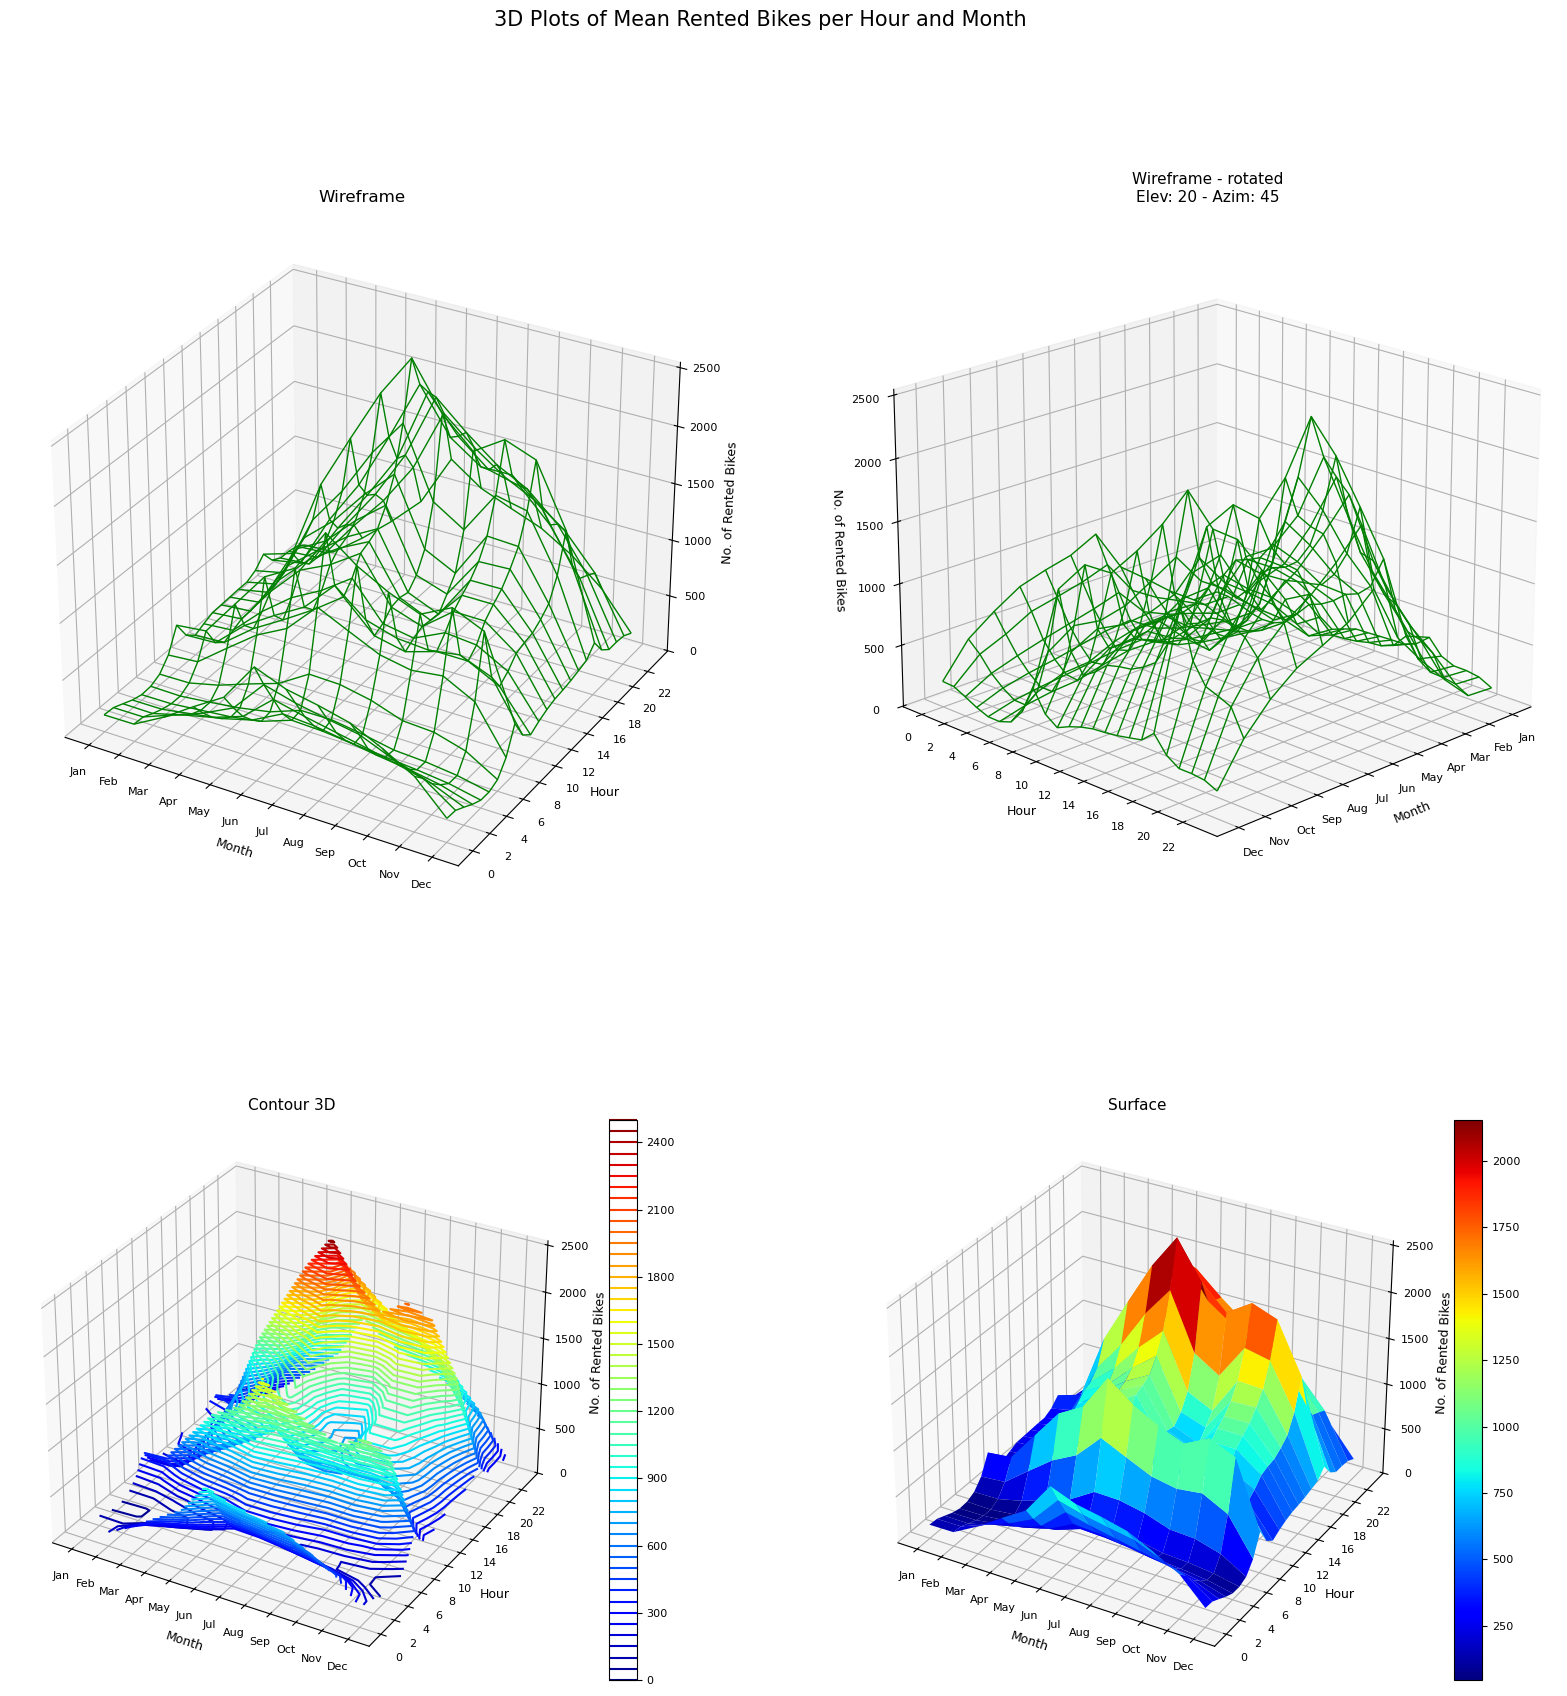

In [73]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(figsize = (20,20), 
        nrows =2, ncols = 2, subplot_kw=dict(projection='3d'))
fig.suptitle('3D Plots of Mean Rented Bikes per Hour and Month', 
             fontsize = 15)

ax0.plot_wireframe(X, Y, Z, color="green", linewidth = 1)
ax0.set(xticks = range(1,13,1), xticklabels = month_names, xlabel = "Month",
        yticks = range(0,24,2), yticklabels = range(0,24,2), ylabel = "Hour",
        zlabel = "No. of Rented Bikes",
)
ax0.set_title(label = 'Wireframe', fontsize = 12)

ax1.plot_wireframe(X, Y, Z, color="green", linewidth = 1)
ax1.set(xticks = range(1,13,1), xticklabels = month_names, xlabel = "Month",
        yticks = range(0,24,2), yticklabels = range(0,24,2), ylabel = "Hour",
        zlabel = "No. of Rented Bikes")
elev = 20
azim = 45
ax1.view_init(elev = elev, azim = azim)
ax1_title = f"Wireframe - rotated\nElev: {elev} - Azim: {azim}"
ax1.set_title(label = ax1_title, fontsize = 11)

contour_plot = ax2.contour(X, Y, Z, levels = 50, cmap='jet')
ax2.set(xticks = range(1,13,1), xticklabels = month_names,  xlabel = "Month",
       yticks = range(0,24,2), yticklabels = range(0,24,2), ylabel = "Hour",
       zlabel = "No. of Rented Bikes")
ax2.set_title(label = "Contour 3D", fontsize = 11)
fig.colorbar(contour_plot, ax = ax2, shrink = 0.8)

surface_plot = ax3.plot_surface(X, Y, Z, cmap='jet')
ax3.set(xticks = range(1,13,1), xticklabels = month_names,  xlabel = "Month",
        yticks = range(0,24,2), yticklabels = range(0,24,2), ylabel = "Hour",
        zlabel = "No. of Rented Bikes")
ax3.set_title(label = "Surface", fontsize = 11)
fig.colorbar(surface_plot, ax = ax3, shrink = 0.8)
fig.savefig("P2_M3.png", dpi = 300)
plt.show()

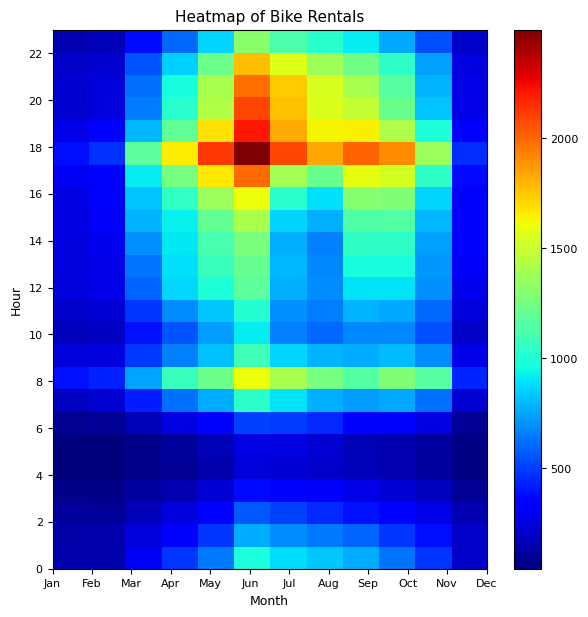

In [74]:
fig, ax = plt.subplots(figsize = (7,7))
img_plot = ax.imshow(Z, extent = [1, 12, 0, 23], origin = 'lower', cmap='jet', aspect = 'auto')
fig.colorbar(img_plot, ax = ax)
ax.set(xticks = range(1,13,1), xticklabels = month_names,  xlabel = "Month",
            yticks = range(0,24,2), yticklabels = range(0,24,2), ylabel = "Hour"            
            )
ax.set_title(label = "Heatmap of Bike Rentals", fontsize = 11)
fig.savefig(img_loc+"Image_Plot.png" , dpi = 400)
plt.show()

### Heatmap of Bike Rentals

#### **1. Plot Overview**

This is an **image plot** (or heatmap-like visualization) created with `imshow()`.
It translates numerical values (here, average number of bikes rented) into colors across a 2D grid defined by **month (x-axis)** and **hour (y-axis)**.

* Brighter/warmer colors (yellow/red) indicate higher bike rentals.
* Darker/cooler colors (blue) represent fewer rentals.
  It answers questions like:
  *At what hours and months are bike rentals most intense?*
  *How do patterns vary across the day and year?*

---

#### **2. Code Breakdown**

```python
fig, ax = plt.subplots(figsize=(7,7))
```

* Creates a figure and one axes (`ax`).
* `figsize=(7,7)` makes the plot square for balanced aspect.

```python
img_plot = ax.imshow(Z, extent=[1, 12, 0, 23], origin='lower', cmap='jet', aspect='auto')
```

* `imshow(Z)` displays the 2D array `Z` as an image.
* `extent=[1,12,0,23]` maps array indices to meaningful values:

  * x-axis → months (1–12)
  * y-axis → hours (0–23)
* `origin='lower'` ensures (0,0) starts bottom-left, making hours increase upward.
* `cmap='jet'` applies the rainbow colormap.
* `aspect='auto'` stretches/squeezes cells to fit figure size.

```python
fig.colorbar(img_plot, ax=ax)
```

* Adds a color scale legend on the side, linking colors to rental counts.

```python
ax.set(xticks=range(1,13,1), xticklabels=month_names, xlabel="Month",
       yticks=range(0,24,2), yticklabels=range(0,24,2), ylabel="Hour")
```

* Customizes axis ticks:

  * x-axis: months labeled Jan–Dec.
  * y-axis: hours shown every 2 hours.
* Sets axis labels.

```python
ax.set_title(label="Heatmap of Bike Rentals", fontsize=11)
```

* Adds a title.

```python
fig.savefig(img_loc+"Image_Plot.png", dpi=400)
```

* Saves the figure with high resolution.

```python
plt.show()
```

* Displays the plot.

---

#### **3. Questions for Reflecting on Visual Elements**

* What do you notice about how the color gradient encodes bike rental intensity?
* How does the colorbar help interpret the meaning of red vs. blue zones?

---

#### **4. Data Interpretation: Explore these questions to deepen your understanding**

* During which hours of the day is demand highest? 
* Which months show the greatest activity overall? 
* Are there times when rentals drop across all months 
* What insights could a bike-sharing company act on with this information (e.g., adjusting bike availability seasonally and hourly)?

---

#### **5. Learning Points**

* `imshow()` is a powerful way to map numeric grids directly to color.
* The `extent` parameter is crucial to give real-world meaning to pixel positions.
* Colorbars are essential for interpretation in heatmap-style plots.
* Common mistakes:

  * Forgetting `origin='lower'` flips the image upside-down.

---

This image plot is essentially a calendar-hour heatmap, letting you spot peaks in bike demand at a glance.

